In [1]:
from ase.build import molecule
from mace.calculators import mace_polar

models = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

for output_name, model_name in models.items():
    print(f"\nTesting {output_name} using model='{model_name}'")

    try:
        calc = mace_polar(
            model=model_name,
            device="cpu",
            default_dtype="float32"
        )

        atoms = molecule("H2O")

        atoms.info["charge"] = 0
        atoms.info["spin"] = 1
        atoms.info["external_field"] = [0.0, 0.0, 0.0]

        atoms.calc = calc

        energy = atoms.get_potential_energy()

        print(f"{output_name} energy = {energy:.8f} eV")
        print("Status: OK")

    except Exception as error:
        print(f"Status: FAILED for {output_name}")
        print(error)

c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\e3nn\o3\_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.

Testing mace-polar-1-s using model='polar-1-s'
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Smodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


mace-polar-1-s energy = -2079.86328125 eV
Status: OK

Testing mace-polar-1-m using model='polar-1-m'
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


mace-polar-1-m energy = -2079.86254883 eV
Status: OK

Testing mace-polar-1-l using model='polar-1-l'
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Lmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


mace-polar-1-l energy = -2079.86328125 eV
Status: OK


In [8]:
from pathlib import Path
import pandas as pd

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"
xyz_dir = project_dir / "xyz_files"

print("Project folder:")
print(project_dir)

print("\nRequired folders:")
for folder in [analysis_dir, info_dir, xyz_dir]:
    print(folder, "FOUND" if folder.exists() else "MISSING")

print("\nRequired files:")
required_files = [
    analysis_dir / "Molecule_Energies.csv",
    analysis_dir / "Reaction_Energies.csv",
    analysis_dir / "Results_values.csv",
    info_dir / "DatasetEval.csv",
    info_dir / "Datasets.csv",
    info_dir / "FD_stepsize.csv",
    info_dir / "Standard_errors.csv",
]

for file in required_files:
    print(file, "FOUND" if file.exists() else "MISSING")

print("\nNumber of xyz files:")
xyz_files = list(xyz_dir.glob("*.xyz"))
print(len(xyz_files))

print("\nFirst 5 xyz files:")
for file in xyz_files[:5]:
    print(file.name)

df_eval = pd.read_csv(info_dir / "DatasetEval.csv")
print("\nDatasetEval.csv columns:")
print(df_eval.columns.tolist())

print("\nFirst stoichiometry:")
print(df_eval["Stoichiometry"].iloc[0])

Project folder:
C:\Users\91988\GSCDB

Required folders:
C:\Users\91988\GSCDB\Analysis FOUND
C:\Users\91988\GSCDB\Info FOUND
C:\Users\91988\GSCDB\xyz_files FOUND

Required files:
C:\Users\91988\GSCDB\Analysis\Molecule_Energies.csv FOUND
C:\Users\91988\GSCDB\Analysis\Reaction_Energies.csv FOUND
C:\Users\91988\GSCDB\Analysis\Results_values.csv FOUND
C:\Users\91988\GSCDB\Info\DatasetEval.csv FOUND
C:\Users\91988\GSCDB\Info\Datasets.csv FOUND
C:\Users\91988\GSCDB\Info\FD_stepsize.csv FOUND
C:\Users\91988\GSCDB\Info\Standard_errors.csv FOUND

Number of xyz files:
14006

First 5 xyz files:
01a_water_dimAB_3B-69.xyz
01a_water_dimAC_3B-69.xyz
01a_water_dimBC_3B-69.xyz
01a_water_monA_3B-69.xyz
01a_water_monB_3B-69.xyz

DatasetEval.csv columns:
['Reaction', 'Dataset', 'Reference', 'Stoichiometry']

First stoichiometry:
1,01a_water_trim_3B-69,1,01a_water_monA_3B-69,1,01a_water_monB_3B-69,1,01a_water_monC_3B-69,-1,01a_water_dimAB_3B-69,-1,01a_water_dimBC_3B-69,-1,01a_water_dimAC_3B-69


In [9]:
from pathlib import Path
from ase.io import read

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]
xyz_dir = project_dir / "xyz_files"

molecule_name = "01_water-ammonia_0p9_dim_A21x12"
xyz_file = xyz_dir / f"{molecule_name}.xyz"

print("XYZ file:")
print(xyz_file)

print("\nExists?")
print(xyz_file.exists())

atoms = read(xyz_file)

print("\nAtoms object:")
print(atoms)

print("\nChemical symbols:")
print(atoms.get_chemical_symbols())

print("\nNumber of atoms:")
print(len(atoms))

XYZ file:
C:\Users\91988\GSCDB\xyz_files\01_water-ammonia_0p9_dim_A21x12.xyz

Exists?
True

Atoms object:
Atoms(symbols='OH2NH3', pbc=False)

Chemical symbols:
['O', 'H', 'H', 'N', 'H', 'H', 'H']

Number of atoms:
7


In [1]:
from pathlib import Path
from ase.io import read
from mace.calculators import mace_polar

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]
xyz_dir = project_dir / "xyz_files"

molecule_name = "01_water-ammonia_0p9_dim_A21x12"
xyz_file = xyz_dir / f"{molecule_name}.xyz"

atoms = read(xyz_file)

atoms.info["charge"] = 0
atoms.info["spin"] = 1
atoms.info["external_field"] = [0.0, 0.0, 0.0]

calc = mace_polar(
    model="polar-1-s",
    device="cpu",
    default_dtype="float32"
)

atoms.calc = calc

energy_ev = atoms.get_potential_energy()

print("Molecule:", molecule_name)
print("Energy:", energy_ev, "eV")

c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\e3nn\o3\_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Smodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


: 

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

# -----------------------------
# Paths
# -----------------------------
project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"
xyz_dir = project_dir / "xyz_files"

dataset_eval_file = info_dir / "DatasetEval.csv"

output_file = analysis_dir / "Molecule_Energies_MACE_POLAR_BH28.csv"


# -----------------------------
# Settings
# -----------------------------
dataset_name = "BH28"

device = "cpu"
default_dtype = "float64"

mace_models = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

# For faster first test, use only small model:
# mace_models = {
#     "mace-polar-1-s": "polar-1-s",
# }

# -----------------------------
# Load DatasetEval.csv
# -----------------------------
df_eval = pd.read_csv(dataset_eval_file, index_col=0)

df_dataset = df_eval[df_eval["Dataset"] == dataset_name].copy()

if df_dataset.empty:
    raise ValueError(f"No rows found for Dataset = {dataset_name}")

print(f"Number of {dataset_name} reactions:")
print(len(df_dataset))

# -----------------------------
# Extract unique molecules used in BH28
# -----------------------------
all_molecules = set()

for stoich_string in df_dataset["Stoichiometry"].dropna():
    parts = [part.strip() for part in stoich_string.split(",")]

    # Stoichiometry format:
    # coeff_1, molecule_1, coeff_2, molecule_2, ...
    for i in range(1, len(parts), 2):
        molecule_name = parts[i]
        all_molecules.add(molecule_name)

all_molecules = sorted(all_molecules)

print(f"\nNumber of unique molecules in {dataset_name}:")
print(len(all_molecules))

print("\nFirst 20 molecules:")
print(all_molecules[:20])

# -----------------------------
# Load MACE-POLAR calculators
# -----------------------------
calculators = {}

for output_column, model_name in mace_models.items():
    print(f"\nLoading {output_column} using model = {model_name}")

    calculators[output_column] = mace_polar(
        model=model_name,
        device=device,
        default_dtype=default_dtype
    )

# -----------------------------
# Calculate molecular energies
# -----------------------------
df_mace = pd.DataFrame(index=all_molecules)
error_log = []

for molecule_name in tqdm(all_molecules, desc=f"Calculating {dataset_name} MACE-POLAR molecular energies"):

    xyz_file = xyz_dir / f"{molecule_name}.xyz"

    if not xyz_file.exists():
        error_log.append({
            "Molecule": molecule_name,
            "Model": "all",
            "Reason": f"Missing xyz file: {xyz_file}"
        })

        for output_column in mace_models:
            df_mace.loc[molecule_name, output_column] = np.nan

        continue

    try:
        atoms = read(xyz_file)

    except Exception as error:
        error_log.append({
            "Molecule": molecule_name,
            "Model": "all",
            "Reason": f"ASE read failed: {error}"
        })

        for output_column in mace_models:
            df_mace.loc[molecule_name, output_column] = np.nan

        continue

    # Assumption: neutral closed-shell molecules
    atoms.info["charge"] = 0
    atoms.info["spin"] = 1
    atoms.info["external_field"] = [0.0, 0.0, 0.0]

    for output_column, calc in calculators.items():

        try:
            atoms.calc = calc
            energy_ev = atoms.get_potential_energy()

            df_mace.loc[molecule_name, output_column] = energy_ev

        except Exception as error:
            error_log.append({
                "Molecule": molecule_name,
                "Model": output_column,
                "Reason": str(error)
            })

            df_mace.loc[molecule_name, output_column] = np.nan

# -----------------------------
# Save output files
# -----------------------------
df_mace.index.name = "Molecule"
df_mace.to_csv(output_file)

pd.DataFrame(error_log).to_csv(error_log_file, index=False)

print("\nSaved BH28 MACE-POLAR molecular energies to:")
print(output_file)

print("\nSaved error log to:")
print(error_log_file)

print("\nMissing values:")
print(df_mace.isna().sum())

c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\e3nn\o3\_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Number of BH28 reactions:
28

Number of unique molecules in BH28:
57

First 20 molecules:
['BH28_BHDIV_1_min', 'BH28_BHDIV_1_ts', 'BH28_BHDIV_2_min', 'BH28_BHDIV_2_ts', 'BH28_BHDIV_3_min', 'BH28_BHDIV_3_ts', 'BH28_BHPERI_1_min', 'BH28_BHPERI_1_ts', 'BH28_BHPERI_2_min', 'BH28_BHPERI_2_ts', 'BH28_BHPERI_3_min', 'BH28_BHPERI_3_ts', 'BH28_BHPERI_4_min', 'BH28_BHPERI_4_ts', 'BH28_BHPERI_5_min', 'BH28_BHPERI_5_ts', 'BH28_BHPERI_6_min', 'BH28_BHPERI_6_ts', 'BH28_CADBH_1_min', 'BH28_CADBH_1_ts']

Loading mace-polar-1-s using model = polar-1-s
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Smodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-m using model = polar-1-m
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel



Loading mace-polar-1-l using model = polar-1-l
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Lmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
Calculating BH28 MACE-POLAR molecular energies:   0%|          | 0/57 [00:00<?, ?it/s]

: 

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm

# -----------------------------
# Paths
# -----------------------------
project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"

dataset_eval_file = info_dir / "DatasetEval.csv"
reaction_energy_file = analysis_dir / "Reaction_Energies.csv"
mace_molecule_file = analysis_dir / "Molecule_Energies_MACE_POLAR_BH28.csv"

output_file = analysis_dir / "Reaction_Energies_with_MACE_POLAR_BH28.csv"

# -----------------------------
# Constants
# -----------------------------
dataset_name = "BH28"

EV_TO_KCAL_PER_MOL = 23.06054783

mace_columns = [
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l",
]

# -----------------------------
# Load files
# -----------------------------
df_eval = pd.read_csv(dataset_eval_file, index_col=0)
df_reaction = pd.read_csv(reaction_energy_file, index_col=0)
df_mace_mol = pd.read_csv(mace_molecule_file, index_col=0)

df_eval_bh28 = df_eval[df_eval["Dataset"] == dataset_name].copy()
df_reaction_bh28 = df_reaction[df_reaction["Dataset"] == dataset_name].copy()

print(f"Number of BH28 rows in DatasetEval.csv: {len(df_eval_bh28)}")
print(f"Number of BH28 rows in Reaction_Energies.csv: {len(df_reaction_bh28)}")

# -----------------------------
# Calculate BH28 MACE-POLAR reaction energies
# -----------------------------
for idx, row in tqdm(df_eval_bh28.iterrows(), total=len(df_eval_bh28), desc="Calculating BH28 reaction energies"):

    stoich_parts = [part.strip() for part in row["Stoichiometry"].split(",")]

    for mace_col in mace_columns:

        reaction_energy_ev = 0.0
        failed = False

        for i in range(0, len(stoich_parts), 2):
            coefficient = float(stoich_parts[i])
            molecule_name = stoich_parts[i + 1]

            if molecule_name not in df_mace_mol.index:
                print(f"Missing molecule energy: {molecule_name}")
                failed = True
                break

            molecule_energy_ev = df_mace_mol.loc[molecule_name, mace_col]

            if pd.isna(molecule_energy_ev):
                print(f"NaN molecule energy: molecule={molecule_name}, model={mace_col}")
                failed = True
                break

            reaction_energy_ev += coefficient * molecule_energy_ev

        if failed:
            df_reaction.loc[idx, mace_col] = np.nan
        else:
            df_reaction.loc[idx, mace_col] = reaction_energy_ev * EV_TO_KCAL_PER_MOL

# -----------------------------
# Save only BH28 rows with MACE-POLAR columns
# -----------------------------
df_output = df_reaction[df_reaction["Dataset"] == dataset_name].copy()

df_output.to_csv(output_file)

print("\nSaved BH28 reaction energies with MACE-POLAR to:")
print(output_file)

print("\nMissing values in MACE columns:")
print(df_output[mace_columns].isna().sum())

print("\nFirst rows:")
print(df_output[["Dataset", "Reference"] + mace_columns].head())

Number of BH28 rows in DatasetEval.csv: 28
Number of BH28 rows in Reaction_Energies.csv: 28


Calculating BH28 reaction energies: 100%|██████████| 28/28 [00:00<00:00, 457.07it/s]


Saved BH28 reaction energies with MACE-POLAR to:
C:\Users\91988\GSCDB\Analysis\Reaction_Energies_with_MACE_POLAR_BH28.csv

Missing values in MACE columns:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64

First rows:
              Dataset  Reference  mace-polar-1-s  mace-polar-1-m  \
Reaction                                                           
BH28_BHDIV_1     BH28  56.955067       59.329115       57.020808   
BH28_BHDIV_2     BH28  50.095602       50.782749       50.287308   
BH28_BHDIV_3     BH28  65.559273       68.370921       65.758593   
BH28_BHPERI_4    BH28  35.014340       43.227267       37.777411   
BH28_BHPERI_5    BH28  30.999044       34.151680       30.672330   

               mace-polar-1-l  
Reaction                       
BH28_BHDIV_1        58.405792  
BH28_BHDIV_2        50.670149  
BH28_BHDIV_3        64.362349  
BH28_BHPERI_4       36.516287  
BH28_BHPERI_5       30.514690  



Correlation analysis result
---------------------------
Dataset selected: BH28
X-axis column: Reference
Y-axis column: mace-polar-1-s
Number of data points: 28
RMSE: 4.477151 kcal/mol
MAE: 3.672297 kcal/mol
Pearson r: 0.970572
R-squared: 0.942009
Regression equation: mace-polar-1-s = 0.974615 × Reference +2.085515


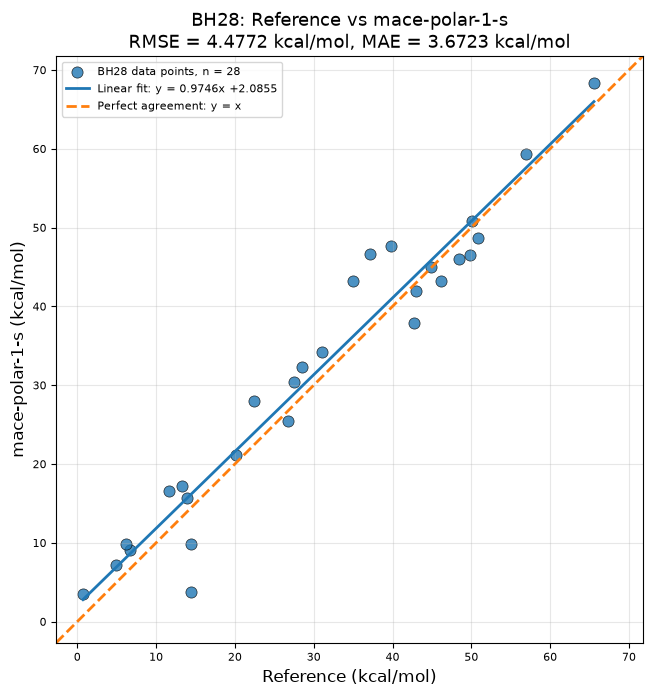


Correlation analysis result
---------------------------
Dataset selected: BH28
X-axis column: Reference
Y-axis column: mace-polar-1-m
Number of data points: 28
RMSE: 1.809502 kcal/mol
MAE: 1.360397 kcal/mol
Pearson r: 0.995377
R-squared: 0.990775
Regression equation: mace-polar-1-m = 0.970659 × Reference +1.431110


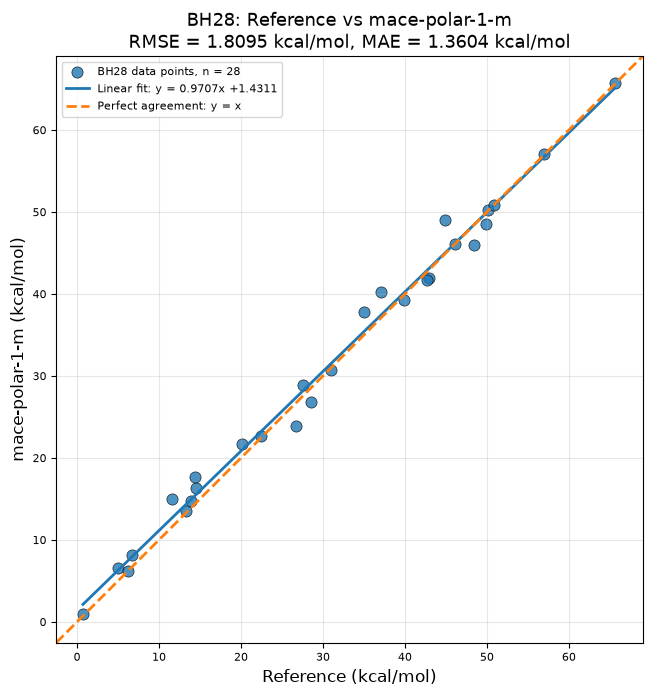


Correlation analysis result
---------------------------
Dataset selected: BH28
X-axis column: Reference
Y-axis column: mace-polar-1-l
Number of data points: 28
RMSE: 1.315516 kcal/mol
MAE: 1.102822 kcal/mol
Pearson r: 0.997329
R-squared: 0.994665
Regression equation: mace-polar-1-l = 0.996875 × Reference +0.370077


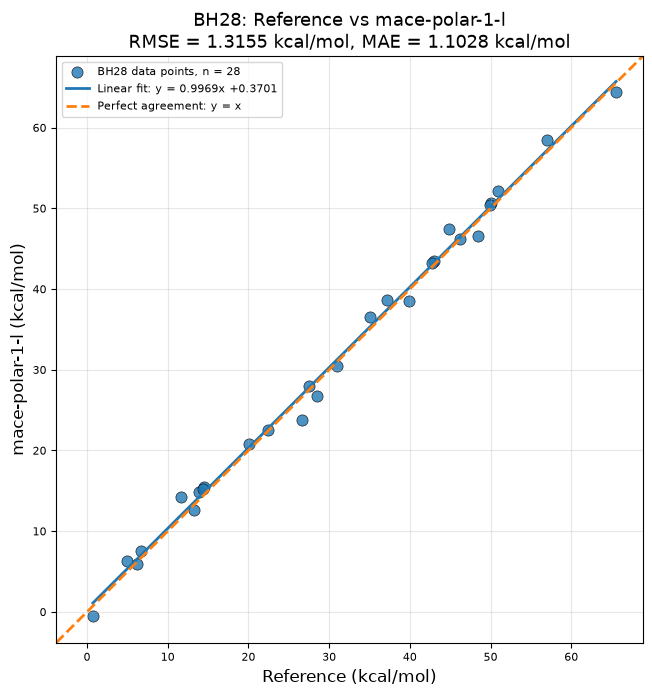

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"

df = pd.read_csv(
    analysis_dir / "Reaction_Energies_with_MACE_POLAR_BH28.csv",
    index_col=0
)


def plot_reference_vs_mace_polar(
    df,
    y_col,
    dataset_value="BH28",
    x_col="Reference",
    unit="kcal/mol"
):
    selected_data = df[df["Dataset"] == dataset_value].copy()

    x = selected_data[x_col].to_numpy()
    y = selected_data[y_col].to_numpy()

    selected_data["Error"] = selected_data[y_col] - selected_data[x_col]
    selected_data["Absolute_Error"] = np.abs(selected_data["Error"])
    selected_data["Squared_Error"] = selected_data["Error"] ** 2

    rmse = np.sqrt(np.mean(selected_data["Squared_Error"]))
    mae = np.mean(selected_data["Absolute_Error"])
    pearson_r = np.corrcoef(x, y)[0, 1]

    slope, intercept = np.polyfit(x, y, 1)
    predicted_y = slope * x + intercept

    ss_residual = np.sum((y - predicted_y) ** 2)
    ss_total = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    sort_order = np.argsort(x)
    x_sorted = x[sort_order]
    predicted_y_sorted = slope * x_sorted + intercept

    minimum_value = min(x.min(), y.min())
    maximum_value = max(x.max(), y.max())
    value_range = maximum_value - minimum_value

    padding = 0.05 * value_range if value_range > 0 else 1.0
    plot_minimum = minimum_value - padding
    plot_maximum = maximum_value + padding

    print("\nCorrelation analysis result")
    print("---------------------------")
    print(f"Dataset selected: {dataset_value}")
    print(f"X-axis column: {x_col}")
    print(f"Y-axis column: {y_col}")
    print(f"Number of data points: {len(selected_data)}")
    print(f"RMSE: {rmse:.6f} {unit}")
    print(f"MAE: {mae:.6f} {unit}")
    print(f"Pearson r: {pearson_r:.6f}")
    print(f"R-squared: {r_squared:.6f}")
    print(f"Regression equation: {y_col} = {slope:.6f} × {x_col} {intercept:+.6f}")

    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y,
        s=65,
        alpha=0.8,
        edgecolors="black",
        linewidths=0.5,
        label=f"{dataset_value} data points, n = {len(selected_data)}"
    )

    plt.plot(
        x_sorted,
        predicted_y_sorted,
        linewidth=2,
        label=f"Linear fit: y = {slope:.4f}x {intercept:+.4f}"
    )

    plt.plot(
        [plot_minimum, plot_maximum],
        [plot_minimum, plot_maximum],
        linestyle="--",
        linewidth=2,
        label="Perfect agreement: y = x"
    )

    plt.xlim(plot_minimum, plot_maximum)
    plt.ylim(plot_minimum, plot_maximum)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"{x_col} ({unit})", fontsize=12)
    plt.ylabel(f"{y_col} ({unit})", fontsize=12)

    plt.title(
        f"{dataset_value}: {x_col} vs {y_col}\n"
        f"RMSE = {rmse:.4f} {unit}, "
        f"MAE = {mae:.4f} {unit}",
        fontsize=13
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    results = {
        "dataset": dataset_value,
        "x_column": x_col,
        "y_column": y_col,
        "unit": unit,
        "n_points": len(selected_data),
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r,
        "r_squared": r_squared,
        "slope": slope,
        "intercept": intercept
    }

    return results, selected_data


results_s, BH28_mace_polar_s_data = plot_reference_vs_mace_polar(
    df=df,
    y_col="mace-polar-1-s"
)

results_m, BH28_mace_polar_m_data = plot_reference_vs_mace_polar(
    df=df,
    y_col="mace-polar-1-m"
)

results_l, BH28_mace_polar_l_data = plot_reference_vs_mace_polar(
    df=df,
    y_col="mace-polar-1-l"
)

Loaded file:
C:\Users\91988\GSCDB\Analysis\Reaction_Energies_with_MACE_POLAR_BH28.csv

Available columns:
['Dataset', 'Reference', 'wB97M2', 'B3LYP', 'BMK', 'CAMB3LYP', 'CF22D', 'M052X', 'M062X', 'M08HX', 'MN15', 'PBE0', 'PW6B95', 'SOGGA11X', 'r2SCAN0', 'wB97M-V', 'wB97X-V', 'revDSD-PBEP86-D4', 'mace-polar-1-s', 'mace-polar-1-m', 'mace-polar-1-l']

Combined correlation analysis
-----------------------------
Dataset selected: BH28
X-axis column: Reference
Y-axis columns: wB97M-V, mace-polar-1-s
Unit: kcal/mol
Number of data points: 28

wB97M-V metrics:
RMSE: 1.285163 kcal/mol
MAE: 0.985091 kcal/mol
Pearson r: 0.997369
R-squared: 0.994744
Regression equation: wB97M-V = 0.997368 × Reference +0.223663

mace-polar-1-s metrics:
RMSE: 4.477151 kcal/mol
MAE: 3.672297 kcal/mol
Pearson r: 0.970572
R-squared: 0.942009
Regression equation: mace-polar-1-s = 0.974615 × Reference +2.085515

Saved plot to:
C:\Users\91988\GSCDB\Analysis\Figures\BH28_Reference_vs_wB97M-V_and_mace-polar-1-s.png


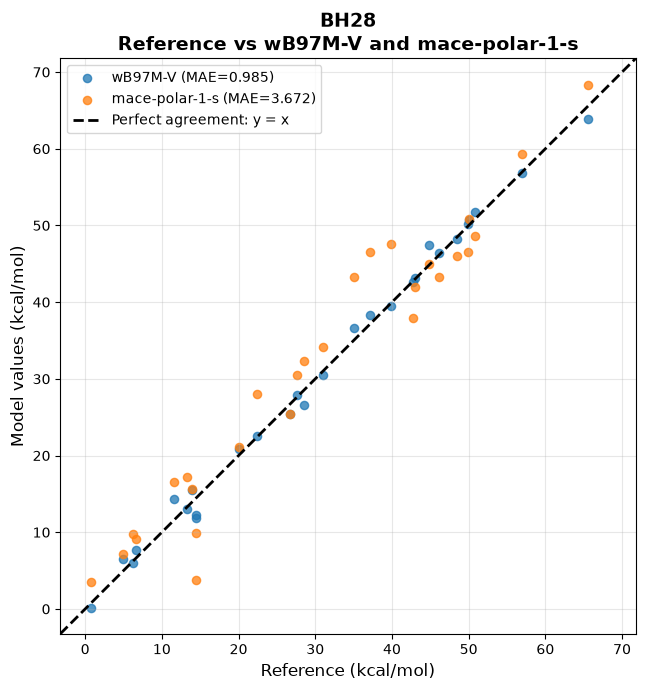


Combined correlation analysis
-----------------------------
Dataset selected: BH28
X-axis column: Reference
Y-axis columns: wB97M-V, mace-polar-1-m
Unit: kcal/mol
Number of data points: 28

wB97M-V metrics:
RMSE: 1.285163 kcal/mol
MAE: 0.985091 kcal/mol
Pearson r: 0.997369
R-squared: 0.994744
Regression equation: wB97M-V = 0.997368 × Reference +0.223663

mace-polar-1-m metrics:
RMSE: 1.809502 kcal/mol
MAE: 1.360397 kcal/mol
Pearson r: 0.995377
R-squared: 0.990775
Regression equation: mace-polar-1-m = 0.970659 × Reference +1.431110

Saved plot to:
C:\Users\91988\GSCDB\Analysis\Figures\BH28_Reference_vs_wB97M-V_and_mace-polar-1-m.png


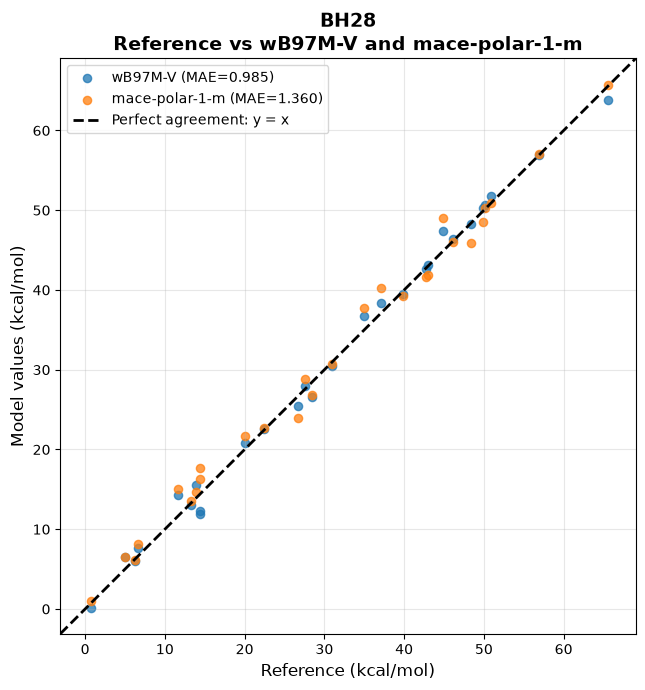


Combined correlation analysis
-----------------------------
Dataset selected: BH28
X-axis column: Reference
Y-axis columns: wB97M-V, mace-polar-1-l
Unit: kcal/mol
Number of data points: 28

wB97M-V metrics:
RMSE: 1.285163 kcal/mol
MAE: 0.985091 kcal/mol
Pearson r: 0.997369
R-squared: 0.994744
Regression equation: wB97M-V = 0.997368 × Reference +0.223663

mace-polar-1-l metrics:
RMSE: 1.315516 kcal/mol
MAE: 1.102822 kcal/mol
Pearson r: 0.997329
R-squared: 0.994665
Regression equation: mace-polar-1-l = 0.996875 × Reference +0.370077

Saved plot to:
C:\Users\91988\GSCDB\Analysis\Figures\BH28_Reference_vs_wB97M-V_and_mace-polar-1-l.png


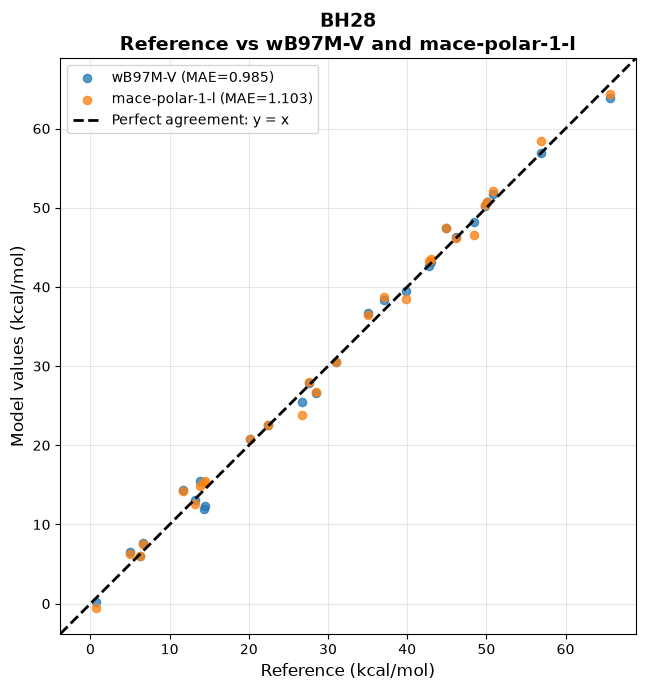


Saved summary file to:
C:\Users\91988\GSCDB\Analysis\BH28_Reference_vs_wB97MV_and_MACE_summary.csv

Summary table:
  dataset   x_column dft_column     mace_column      unit  n_points  dft_rmse  \
0    BH28  Reference    wB97M-V  mace-polar-1-s  kcal/mol        28  1.285163   
1    BH28  Reference    wB97M-V  mace-polar-1-m  kcal/mol        28  1.285163   
2    BH28  Reference    wB97M-V  mace-polar-1-l  kcal/mol        28  1.285163   

    dft_mae  dft_pearson_r  dft_r_squared  dft_slope  dft_intercept  \
0  0.985091       0.997369       0.994744   0.997368       0.223663   
1  0.985091       0.997369       0.994744   0.997368       0.223663   
2  0.985091       0.997369       0.994744   0.997368       0.223663   

   mace_rmse  mace_mae  mace_pearson_r  mace_r_squared  mace_slope  \
0   4.477151  3.672297        0.970572        0.942009    0.974615   
1   1.809502  1.360397        0.995377        0.990775    0.970659   
2   1.315516  1.102822        0.997329        0.994665    0.9968

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
figures_dir = analysis_dir / "Figures"
figures_dir.mkdir(exist_ok=True)

input_file = analysis_dir / "Reaction_Energies_with_MACE_POLAR_BH28.csv"

# -----------------------------
# Read file
# -----------------------------
df = pd.read_csv(input_file, index_col=0)

print("Loaded file:")
print(input_file)

print("\nAvailable columns:")
print(df.columns.tolist())


def calculate_metrics(x, y):
    error = y - x
    absolute_error = np.abs(error)
    squared_error = error ** 2

    rmse = np.sqrt(np.mean(squared_error))
    mae = np.mean(absolute_error)
    pearson_r = np.corrcoef(x, y)[0, 1]

    slope, intercept = np.polyfit(x, y, 1)
    predicted_y = slope * x + intercept

    ss_residual = np.sum((y - predicted_y) ** 2)
    ss_total = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    return {
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r,
        "r_squared": r_squared,
        "slope": slope,
        "intercept": intercept
    }


def plot_reference_vs_two_models(
    df,
    dataset_value,
    dft_col,
    mace_col,
    x_col="Reference",
    dataset_col="Dataset",
    unit="kcal/mol",
    save_plot=True
):
    # -----------------------------
    # Filter BH28 rows
    # -----------------------------
    selected_data = df[df[dataset_col] == dataset_value].copy()

    if selected_data.empty:
        raise ValueError(f"No rows found for {dataset_col} = '{dataset_value}'")

    required_columns = [x_col, dft_col, mace_col]
    for col in required_columns:
        if col not in selected_data.columns:
            raise ValueError(f"Column '{col}' was not found in the data.")

    # -----------------------------
    # Define data
    # -----------------------------
    x = selected_data[x_col].to_numpy()
    y_dft = selected_data[dft_col].to_numpy()
    y_mace = selected_data[mace_col].to_numpy()

    # -----------------------------
    # Calculate metrics
    # -----------------------------
    dft_metrics = calculate_metrics(x, y_dft)
    mace_metrics = calculate_metrics(x, y_mace)

    # -----------------------------
    # Plot limits
    # -----------------------------
    minimum_value = min(x.min(), y_dft.min(), y_mace.min())
    maximum_value = max(x.max(), y_dft.max(), y_mace.max())
    value_range = maximum_value - minimum_value

    padding = 0.05 * value_range if value_range > 0 else 1.0
    plot_minimum = minimum_value - padding
    plot_maximum = maximum_value + padding

    # -----------------------------
    # Print summary
    # -----------------------------
    print("\nCombined correlation analysis")
    print("-----------------------------")
    print(f"Dataset selected: {dataset_value}")
    print(f"X-axis column: {x_col}")
    print(f"Y-axis columns: {dft_col}, {mace_col}")
    print(f"Unit: {unit}")
    print(f"Number of data points: {len(selected_data)}")

    print(f"\n{dft_col} metrics:")
    print(f"RMSE: {dft_metrics['rmse']:.6f} {unit}")
    print(f"MAE: {dft_metrics['mae']:.6f} {unit}")
    print(f"Pearson r: {dft_metrics['pearson_r']:.6f}")
    print(f"R-squared: {dft_metrics['r_squared']:.6f}")
    print(f"Regression equation: {dft_col} = {dft_metrics['slope']:.6f} × {x_col} {dft_metrics['intercept']:+.6f}")

    print(f"\n{mace_col} metrics:")
    print(f"RMSE: {mace_metrics['rmse']:.6f} {unit}")
    print(f"MAE: {mace_metrics['mae']:.6f} {unit}")
    print(f"Pearson r: {mace_metrics['pearson_r']:.6f}")
    print(f"R-squared: {mace_metrics['r_squared']:.6f}")
    print(f"Regression equation: {mace_col} = {mace_metrics['slope']:.6f} × {x_col} {mace_metrics['intercept']:+.6f}")

    # -----------------------------
    # Generate plot
    # -----------------------------
    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y_dft,
        s=35,
        alpha=0.75,
        label=f"{dft_col} (MAE={dft_metrics['mae']:.3f})"
    )

    plt.scatter(
        x,
        y_mace,
        s=35,
        alpha=0.75,
        label=f"{mace_col} (MAE={mace_metrics['mae']:.3f})"
    )

    plt.plot(
        [plot_minimum, plot_maximum],
        [plot_minimum, plot_maximum],
        linestyle="--",
        linewidth=2,
        color="black",
        label="Perfect agreement: y = x"
    )

    plt.xlim(plot_minimum, plot_maximum)
    plt.ylim(plot_minimum, plot_maximum)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"{x_col} ({unit})", fontsize=12)
    plt.ylabel(f"Model values ({unit})", fontsize=12)

    plt.title(
        f"{dataset_value}\n"
        f"{x_col} vs {dft_col} and {mace_col}",
        fontsize=14,
        fontweight="bold"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if save_plot:
        output_plot = figures_dir / f"{dataset_value}_{x_col}_vs_{dft_col}_and_{mace_col}.png"
        plt.savefig(output_plot, dpi=300)
        print("\nSaved plot to:")
        print(output_plot)

    plt.show()

    # -----------------------------
    # Save metrics in dictionary
    # -----------------------------
    results = {
        "dataset": dataset_value,
        "x_column": x_col,
        "dft_column": dft_col,
        "mace_column": mace_col,
        "unit": unit,
        "n_points": len(selected_data),

        "dft_rmse": dft_metrics["rmse"],
        "dft_mae": dft_metrics["mae"],
        "dft_pearson_r": dft_metrics["pearson_r"],
        "dft_r_squared": dft_metrics["r_squared"],
        "dft_slope": dft_metrics["slope"],
        "dft_intercept": dft_metrics["intercept"],

        "mace_rmse": mace_metrics["rmse"],
        "mace_mae": mace_metrics["mae"],
        "mace_pearson_r": mace_metrics["pearson_r"],
        "mace_r_squared": mace_metrics["r_squared"],
        "mace_slope": mace_metrics["slope"],
        "mace_intercept": mace_metrics["intercept"],
    }

    return results, selected_data


# -----------------------------
# Generate the 3 required plots
# -----------------------------
mace_models = [
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l"
]

all_results = []

for mace_col in mace_models:
    results, data = plot_reference_vs_two_models(
        df=df,
        dataset_value="BH28",
        dft_col="wB97M-V",
        mace_col=mace_col,
        x_col="Reference",
        unit="kcal/mol",
        save_plot=True
    )
    all_results.append(results)

# -----------------------------
# Save summary file
# -----------------------------
summary_df = pd.DataFrame(all_results)

summary_file = analysis_dir / "BH28_Reference_vs_wB97MV_and_MACE_summary.csv"
summary_df.to_csv(summary_file, index=False)

print("\nSaved summary file to:")
print(summary_file)

print("\nSummary table:")
print(summary_df)

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

# -----------------------------
# Paths
# -----------------------------
project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"
xyz_dir = project_dir / "xyz_files"

dataset_eval_file = info_dir / "DatasetEval.csv"

output_file = analysis_dir / "Molecule_Energies_MACE_POLAR_BHPERI11.csv"
error_log_file = analysis_dir / "Molecule_Energies_MACE_POLAR_BHPERI11_error_log.csv"

# -----------------------------
# Settings
# -----------------------------
dataset_name = "BHPERI11"

device = "cpu"
default_dtype = "float32"

mace_models = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

# For faster first test, use only small model:
# mace_models = {
#     "mace-polar-1-s": "polar-1-s",
# }

# -----------------------------
# Load DatasetEval.csv
# -----------------------------
df_eval = pd.read_csv(dataset_eval_file, index_col=0)

df_dataset = df_eval[df_eval["Dataset"] == dataset_name].copy()

if df_dataset.empty:
    raise ValueError(f"No rows found for Dataset = {dataset_name}")

print(f"Number of {dataset_name} reactions:")
print(len(df_dataset))

# -----------------------------
# Extract unique molecules used in BHPERI11
# -----------------------------
all_molecules = set()

for stoich_string in df_dataset["Stoichiometry"].dropna():
    parts = [part.strip() for part in stoich_string.split(",")]

    for i in range(1, len(parts), 2):
        molecule_name = parts[i]
        all_molecules.add(molecule_name)

all_molecules = sorted(all_molecules)

print(f"\nNumber of unique molecules in {dataset_name}:")
print(len(all_molecules))

print("\nFirst 20 molecules:")
print(all_molecules[:20])

# -----------------------------
# Load MACE-POLAR calculators
# -----------------------------
calculators = {}

for output_column, model_name in mace_models.items():
    print(f"\nLoading {output_column} using model = {model_name}")

    calculators[output_column] = mace_polar(
        model=model_name,
        device=device,
        default_dtype=default_dtype
    )

# -----------------------------
# Calculate molecular energies
# -----------------------------
df_mace = pd.DataFrame(index=all_molecules)
error_log = []

for molecule_name in tqdm(all_molecules, desc=f"Calculating {dataset_name} MACE-POLAR molecular energies"):

    xyz_file = xyz_dir / f"{molecule_name}.xyz"

    if not xyz_file.exists():
        error_log.append({
            "Molecule": molecule_name,
            "Model": "all",
            "Reason": f"Missing xyz file: {xyz_file}"
        })

        for output_column in mace_models:
            df_mace.loc[molecule_name, output_column] = np.nan

        continue

    try:
        atoms = read(xyz_file)

    except Exception as error:
        error_log.append({
            "Molecule": molecule_name,
            "Model": "all",
            "Reason": f"ASE read failed: {error}"
        })

        for output_column in mace_models:
            df_mace.loc[molecule_name, output_column] = np.nan

        continue

    # For BHPERI11, use zero external field.
    # Assumption: neutral closed-shell molecule.
    atoms.info["charge"] = 0
    atoms.info["spin"] = 1
    atoms.info["external_field"] = [0.0, 0.0, 0.0]

    for output_column, calc in calculators.items():

        try:
            atoms.calc = calc
            energy_ev = atoms.get_potential_energy()

            df_mace.loc[molecule_name, output_column] = energy_ev

        except Exception as error:
            error_log.append({
                "Molecule": molecule_name,
                "Model": output_column,
                "Reason": str(error)
            })

            df_mace.loc[molecule_name, output_column] = np.nan

# -----------------------------
# Save output files
# -----------------------------
df_mace.index.name = "Molecule"
df_mace.to_csv(output_file)

pd.DataFrame(error_log).to_csv(error_log_file, index=False)

print("\nSaved BHPERI11 MACE-POLAR molecular energies to:")
print(output_file)

print("\nSaved error log to:")
print(error_log_file)

print("\nMissing values:")
print(df_mace.isna().sum())

Number of BHPERI11 reactions:
11

Number of unique molecules in BHPERI11:
22

First 20 molecules:
['BHPERI_00r', 'BHPERI_02r', 'BHPERI_02ts', 'BHPERI_03r', 'BHPERI_03ts', 'BHPERI_04r', 'BHPERI_04ts', 'BHPERI_05r', 'BHPERI_06ts', 'BHPERI_07r', 'BHPERI_07ts', 'BHPERI_08ts', 'BHPERI_09r', 'BHPERI_09ts', 'BHPERI_1-3-Cyclopentadiene', 'BHPERI_Cis-triscyclopropacyclohexane', 'BHPERI_Ethylene', 'BHPERI_TS11', 'BHPERI_TS3', 'BHPERI_TS8']

Loading mace-polar-1-s using model = polar-1-s
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Smodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-m using model = polar-1-m
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-l using model = polar-1-l
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Lmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
Calculating BHPERI11 MACE-POLAR molecular energies: 100%|██████████| 22/22 [01:16<00:00,  3.47s/it]


Saved BHPERI11 MACE-POLAR molecular energies to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_BHPERI11.csv

Saved error log to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_BHPERI11_error_log.csv

Missing values:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm

# -----------------------------
# Paths
# -----------------------------
project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"

dataset_eval_file = info_dir / "DatasetEval.csv"
reaction_energy_file = analysis_dir / "Reaction_Energies.csv"
mace_molecule_file = analysis_dir / "Molecule_Energies_MACE_POLAR_BHPERI11.csv"

output_file = analysis_dir / "Reaction_Energies_with_MACE_POLAR_BHPERI11.csv"

# -----------------------------
# Constants
# -----------------------------
dataset_name = "BHPERI11"

EV_TO_KCAL_PER_MOL = 23.06054783

mace_columns = [
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l",
]

# -----------------------------
# Load files
# -----------------------------
df_eval = pd.read_csv(dataset_eval_file, index_col=0)
df_reaction = pd.read_csv(reaction_energy_file, index_col=0)
df_mace_mol = pd.read_csv(mace_molecule_file, index_col=0)

df_eval_dataset = df_eval[df_eval["Dataset"] == dataset_name].copy()
df_reaction_dataset = df_reaction[df_reaction["Dataset"] == dataset_name].copy()

print(f"Number of {dataset_name} rows in DatasetEval.csv: {len(df_eval_dataset)}")
print(f"Number of {dataset_name} rows in Reaction_Energies.csv: {len(df_reaction_dataset)}")

# -----------------------------
# Calculate BHPERI11 MACE-POLAR reaction energies
# -----------------------------
for idx, row in tqdm(df_eval_dataset.iterrows(), total=len(df_eval_dataset), desc="Calculating BHPERI11 reaction energies"):

    stoich_parts = [part.strip() for part in row["Stoichiometry"].split(",")]

    for mace_col in mace_columns:

        reaction_energy_ev = 0.0
        failed = False

        for i in range(0, len(stoich_parts), 2):
            coefficient = float(stoich_parts[i])
            molecule_name = stoich_parts[i + 1]

            if molecule_name not in df_mace_mol.index:
                print(f"Missing molecule energy: {molecule_name}")
                failed = True
                break

            molecule_energy_ev = df_mace_mol.loc[molecule_name, mace_col]

            if pd.isna(molecule_energy_ev):
                print(f"NaN molecule energy: molecule={molecule_name}, model={mace_col}")
                failed = True
                break

            reaction_energy_ev += coefficient * molecule_energy_ev

        if failed:
            df_reaction.loc[idx, mace_col] = np.nan
        else:
            df_reaction.loc[idx, mace_col] = reaction_energy_ev * EV_TO_KCAL_PER_MOL

# -----------------------------
# Save only BHPERI11 rows with MACE-POLAR columns
# -----------------------------
df_output = df_reaction[df_reaction["Dataset"] == dataset_name].copy()

df_output.to_csv(output_file)

print("\nSaved BHPERI11 reaction energies with MACE-POLAR to:")
print(output_file)

print("\nMissing values in MACE columns:")
print(df_output[mace_columns].isna().sum())

print("\nFirst rows:")
print(df_output[["Dataset", "Reference", "wB97M-V"] + mace_columns].head())

Number of BHPERI11 rows in DatasetEval.csv: 11
Number of BHPERI11 rows in Reaction_Energies.csv: 11


Calculating BHPERI11 reaction energies: 100%|██████████| 11/11 [00:00<00:00, 682.03it/s]


Saved BHPERI11 reaction energies with MACE-POLAR to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Reaction_Energies_with_MACE_POLAR_BHPERI11.csv

Missing values in MACE columns:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64

First rows:
            Dataset  Reference    wB97M-V  mace-polar-1-s  mace-polar-1-m  \
Reaction                                                                    
BHPERI_3   BHPERI11  28.100021  28.901656       36.797788       31.708253   
BHPERI_8   BHPERI11  18.000014  18.764189       27.277430       19.918999   
BHPERI_9   BHPERI11  14.500011  16.783523       18.556535       21.326503   
BHPERI_10  BHPERI11  26.400020  30.357566       43.891609       37.293230   
BHPERI_20  BHPERI11  18.100014  18.928402       27.283060       19.992189   

           mace-polar-1-l  
Reaction                   
BHPERI_3        29.951688  
BHPERI_8        19.586828  
BHPERI_9        19.502377  
BHPERI_10       32.158655  
BHPERI_20       19.727578  


In [5]:
from pathlib import Path
import pandas as pd

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"

input_file = analysis_dir / "Reaction_Energies_with_MACE_POLAR_BHPERI11.csv"
output_values_file = analysis_dir / "Results_values_with_MACE_POLAR_BHPERI11.csv"
output_errors_file = analysis_dir / "Results_errors_with_MACE_POLAR_BHPERI11.csv"

df_values = pd.read_csv(input_file, index_col=0)

metadata_cols = ["Reaction", "Dataset"]
value_cols = [col for col in df_values.columns if col not in metadata_cols]

df_errors = df_values.copy()

for col in value_cols:
    if col != "Reference":
        df_errors[col] = df_values[col] - df_values["Reference"]

df_values.to_csv(output_values_file)
df_errors.to_csv(output_errors_file)

print("Saved BHPERI11 results values to:")
print(output_values_file)

print("\nSaved BHPERI11 results errors to:")
print(output_errors_file)

print("\nColumns:")
print(df_values.columns.tolist())

Saved BHPERI11 results values to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Results_values_with_MACE_POLAR_BHPERI11.csv

Saved BHPERI11 results errors to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Results_errors_with_MACE_POLAR_BHPERI11.csv

Columns:
['Dataset', 'Reference', 'wB97M2', 'B3LYP', 'BMK', 'CAMB3LYP', 'CF22D', 'M052X', 'M062X', 'M08HX', 'MN15', 'PBE0', 'PW6B95', 'SOGGA11X', 'r2SCAN0', 'wB97M-V', 'wB97X-V', 'revDSD-PBEP86-D4', 'mace-polar-1-s', 'mace-polar-1-m', 'mace-polar-1-l']



Reference vs MACE-POLAR plot
----------------------------
Dataset: BHPERI11
Datatype: Barrier Height
Model: mace-polar-1-s
Unit: kcal/mol
Number of points: 11
RMSE: 11.145275 kcal/mol
MAE: 10.699094 kcal/mol
Pearson r: 0.922147
R²: 0.850356
Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\BHPERI11_Reference_vs_mace-polar-1-s.png


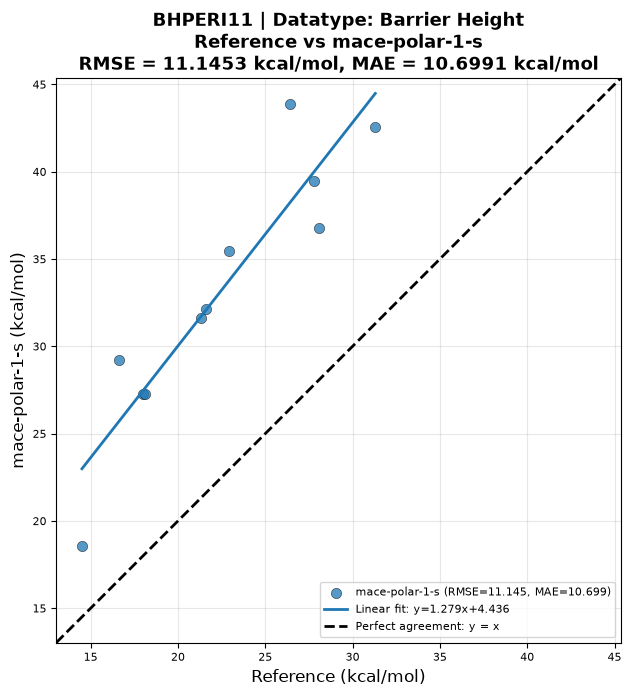


Reference vs MACE-POLAR plot
----------------------------
Dataset: BHPERI11
Datatype: Barrier Height
Model: mace-polar-1-m
Unit: kcal/mol
Number of points: 11
RMSE: 4.547984 kcal/mol
MAE: 3.584800 kcal/mol
Pearson r: 0.886359
R²: 0.785633
Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\BHPERI11_Reference_vs_mace-polar-1-m.png


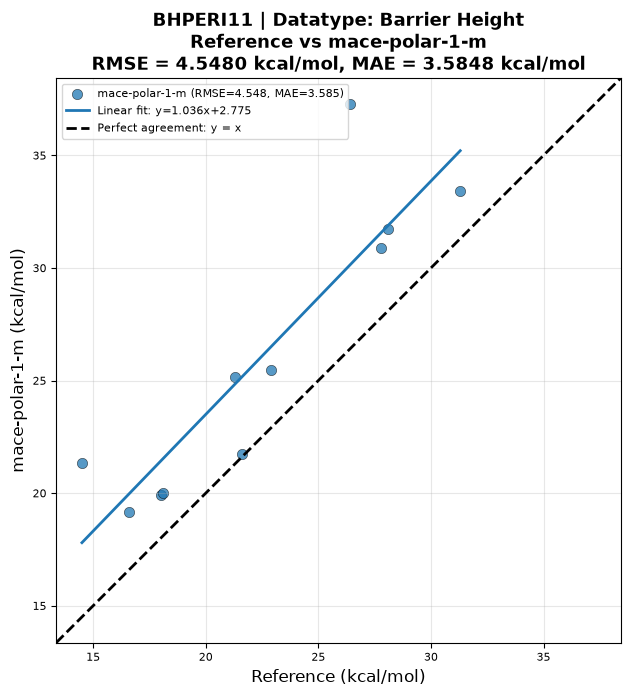


Reference vs MACE-POLAR plot
----------------------------
Dataset: BHPERI11
Datatype: Barrier Height
Model: mace-polar-1-l
Unit: kcal/mol
Number of points: 11
RMSE: 2.703573 kcal/mol
MAE: 2.154248 kcal/mol
Pearson r: 0.953586
R²: 0.909325
Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\BHPERI11_Reference_vs_mace-polar-1-l.png


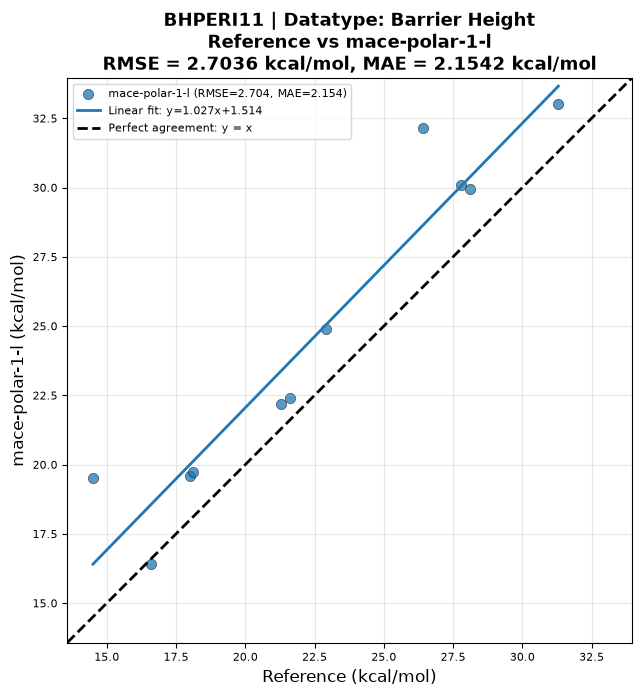


Saved summary to:
C:\Users\91988\GSCDB Benchmarking\Analysis\BHPERI11_Reference_vs_MACE_POLAR_summary.csv

Summary:
    dataset        datatype           model      unit  n_points       rmse  \
0  BHPERI11  Barrier Height  mace-polar-1-s  kcal/mol        11  11.145275   
1  BHPERI11  Barrier Height  mace-polar-1-m  kcal/mol        11   4.547984   
2  BHPERI11  Barrier Height  mace-polar-1-l  kcal/mol        11   2.703573   

         mae  pearson_r  r_squared     slope  intercept  
0  10.699094   0.922147   0.850356  1.279373   4.436056  
1   3.584800   0.886359   0.785633  1.036116   2.775134  
2   2.154248   0.953586   0.909325  1.026982   1.514052  


In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"
figures_dir = analysis_dir / "Figures"
figures_dir.mkdir(exist_ok=True)

dataset_name = "BHPERI11"
unit = "kcal/mol"

input_file = analysis_dir / "Results_values_with_MACE_POLAR_BHPERI11.csv"
datasets_info_file = info_dir / "Datasets.csv"

df = pd.read_csv(input_file, index_col=0)
df_info = pd.read_csv(datasets_info_file)


def get_dataset_info(dataset_name, df_info):
    row = df_info[df_info["Name"] == dataset_name]

    if row.empty:
        datatype = "Unknown"
        description = "No description found"
    else:
        datatype = row["Datatype"].iloc[0]
        description = row["Description"].iloc[0]

    return datatype, description


def calculate_metrics(x, y):
    error = y - x
    absolute_error = np.abs(error)
    squared_error = error ** 2

    rmse = np.sqrt(np.mean(squared_error))
    mae = np.mean(absolute_error)
    pearson_r = np.corrcoef(x, y)[0, 1]

    slope, intercept = np.polyfit(x, y, 1)
    predicted_y = slope * x + intercept

    ss_residual = np.sum((y - predicted_y) ** 2)
    ss_total = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    return {
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r,
        "r_squared": r_squared,
        "slope": slope,
        "intercept": intercept
    }


def plot_reference_vs_single_model(df, dataset_name, model_col):
    datatype, description = get_dataset_info(dataset_name, df_info)

    selected_data = df[df["Dataset"] == dataset_name].copy()

    if selected_data.empty:
        raise ValueError(f"No rows found for Dataset = {dataset_name}")

    required_cols = ["Reference", model_col]

    for col in required_cols:
        if col not in selected_data.columns:
            raise ValueError(f"Column '{col}' not found.")

    x = selected_data["Reference"].to_numpy()
    y = selected_data[model_col].to_numpy()

    metrics = calculate_metrics(x, y)

    min_value = min(x.min(), y.min())
    max_value = max(x.max(), y.max())
    value_range = max_value - min_value

    padding = 0.05 * value_range if value_range > 0 else 1.0
    plot_min = min_value - padding
    plot_max = max_value + padding

    sort_order = np.argsort(x)
    x_sorted = x[sort_order]
    fit_sorted = metrics["slope"] * x_sorted + metrics["intercept"]

    print("\nReference vs MACE-POLAR plot")
    print("----------------------------")
    print(f"Dataset: {dataset_name}")
    print(f"Datatype: {datatype}")
    print(f"Model: {model_col}")
    print(f"Unit: {unit}")
    print(f"Number of points: {len(selected_data)}")
    print(f"RMSE: {metrics['rmse']:.6f} {unit}")
    print(f"MAE: {metrics['mae']:.6f} {unit}")
    print(f"Pearson r: {metrics['pearson_r']:.6f}")
    print(f"R²: {metrics['r_squared']:.6f}")

    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{model_col} (RMSE={metrics['rmse']:.3f}, MAE={metrics['mae']:.3f})"
    )

    plt.plot(
        x_sorted,
        fit_sorted,
        linewidth=2,
        label=f"Linear fit: y={metrics['slope']:.3f}x{metrics['intercept']:+.3f}"
    )

    plt.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
        linewidth=2,
        color="black",
        label="Perfect agreement: y = x"
    )

    plt.xlim(plot_min, plot_max)
    plt.ylim(plot_min, plot_max)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"Reference ({unit})", fontsize=12)
    plt.ylabel(f"{model_col} ({unit})", fontsize=12)

    plt.title(
        f"{dataset_name} | Datatype: {datatype}\n"
        f"Reference vs {model_col}\n"
        f"RMSE = {metrics['rmse']:.4f} {unit}, MAE = {metrics['mae']:.4f} {unit}",
        fontsize=13,
        fontweight="bold"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_plot = figures_dir / f"{dataset_name}_Reference_vs_{model_col}.png"
    plt.savefig(output_plot, dpi=300)

    print("Saved plot to:")
    print(output_plot)

    plt.show()

    result = {
        "dataset": dataset_name,
        "datatype": datatype,
        "model": model_col,
        "unit": unit,
        "n_points": len(selected_data),
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "pearson_r": metrics["pearson_r"],
        "r_squared": metrics["r_squared"],
        "slope": metrics["slope"],
        "intercept": metrics["intercept"],
    }

    return result


mace_models = [
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l"
]

all_results = []

for model_col in mace_models:
    result = plot_reference_vs_single_model(
        df=df,
        dataset_name=dataset_name,
        model_col=model_col
    )

    all_results.append(result)

summary_df = pd.DataFrame(all_results)

summary_file = analysis_dir / f"{dataset_name}_Reference_vs_MACE_POLAR_summary.csv"
summary_df.to_csv(summary_file, index=False)

print("\nSaved summary to:")
print(summary_file)

print("\nSummary:")
print(summary_df)


Combined Reference correlation plot
-----------------------------------
Dataset: BHPERI11
Datatype: Barrier Height
X-axis: Reference
Y-axis series: wB97M-V and mace-polar-1-s
Unit: kcal/mol
Number of points: 11

wB97M-V:
RMSE: 1.629023 kcal/mol
MAE: 1.335941 kcal/mol
Pearson r: 0.985160
R²: 0.970541

mace-polar-1-s:
RMSE: 11.145275 kcal/mol
MAE: 10.699094 kcal/mol
Pearson r: 0.922147
R²: 0.850356

Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\BHPERI11_Reference_vs_wB97M-V_and_mace-polar-1-s.png


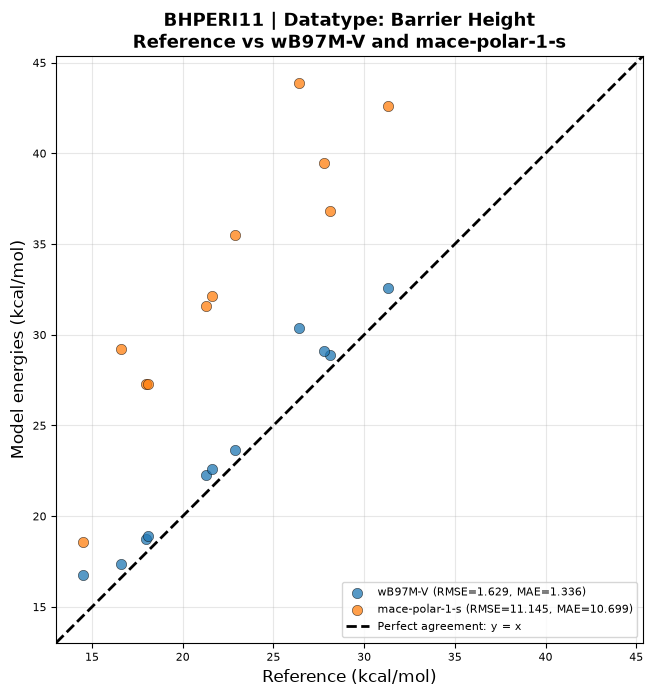


Combined Reference correlation plot
-----------------------------------
Dataset: BHPERI11
Datatype: Barrier Height
X-axis: Reference
Y-axis series: wB97M-V and mace-polar-1-m
Unit: kcal/mol
Number of points: 11

wB97M-V:
RMSE: 1.629023 kcal/mol
MAE: 1.335941 kcal/mol
Pearson r: 0.985160
R²: 0.970541

mace-polar-1-m:
RMSE: 4.547984 kcal/mol
MAE: 3.584800 kcal/mol
Pearson r: 0.886359
R²: 0.785633

Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\BHPERI11_Reference_vs_wB97M-V_and_mace-polar-1-m.png


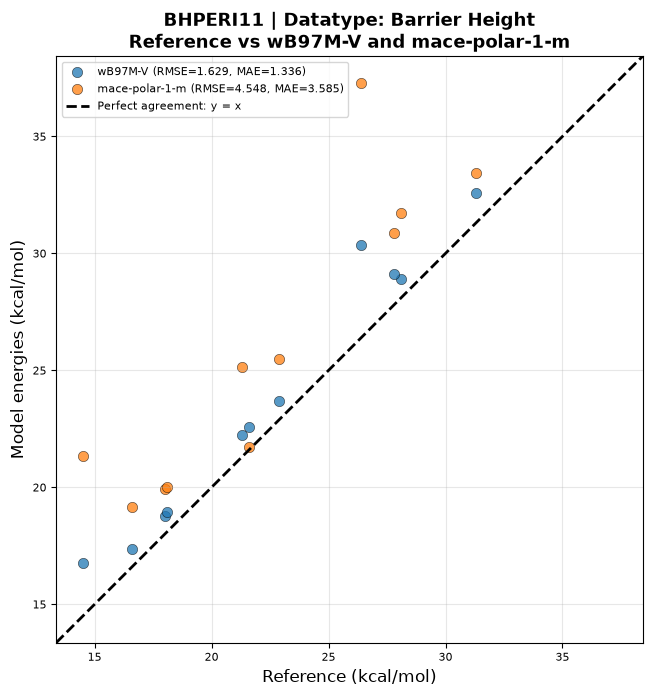


Combined Reference correlation plot
-----------------------------------
Dataset: BHPERI11
Datatype: Barrier Height
X-axis: Reference
Y-axis series: wB97M-V and mace-polar-1-l
Unit: kcal/mol
Number of points: 11

wB97M-V:
RMSE: 1.629023 kcal/mol
MAE: 1.335941 kcal/mol
Pearson r: 0.985160
R²: 0.970541

mace-polar-1-l:
RMSE: 2.703573 kcal/mol
MAE: 2.154248 kcal/mol
Pearson r: 0.953586
R²: 0.909325

Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\BHPERI11_Reference_vs_wB97M-V_and_mace-polar-1-l.png


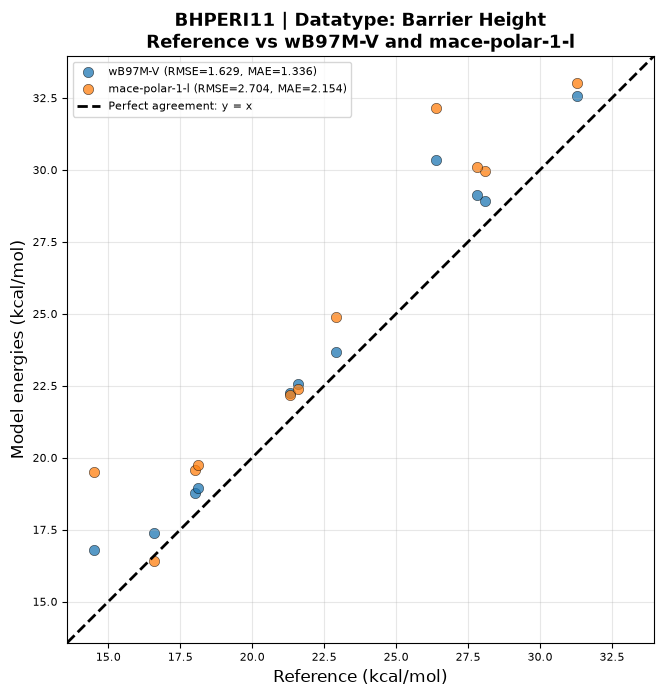


Saved combined summary to:
C:\Users\91988\GSCDB Benchmarking\Analysis\BHPERI11_Reference_vs_wB97MV_and_MACE_summary.csv

Summary:
    dataset        datatype      unit  n_points dft_model  dft_rmse   dft_mae  \
0  BHPERI11  Barrier Height  kcal/mol        11   wB97M-V  1.629023  1.335941   
1  BHPERI11  Barrier Height  kcal/mol        11   wB97M-V  1.629023  1.335941   
2  BHPERI11  Barrier Height  kcal/mol        11   wB97M-V  1.629023  1.335941   

   dft_pearson_r  dft_r_squared      mace_model  mace_rmse   mace_mae  \
0        0.98516       0.970541  mace-polar-1-s  11.145275  10.699094   
1        0.98516       0.970541  mace-polar-1-m   4.547984   3.584800   
2        0.98516       0.970541  mace-polar-1-l   2.703573   2.154248   

   mace_pearson_r  mace_r_squared  
0        0.922147        0.850356  
1        0.886359        0.785633  
2        0.953586        0.909325  


In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"
figures_dir = analysis_dir / "Figures"
figures_dir.mkdir(exist_ok=True)

dataset_name = "BHPERI11"
unit = "kcal/mol"

input_file = analysis_dir / "Results_values_with_MACE_POLAR_BHPERI11.csv"
datasets_info_file = info_dir / "Datasets.csv"

df = pd.read_csv(input_file, index_col=0)
df_info = pd.read_csv(datasets_info_file)


def get_dataset_info(dataset_name, df_info):
    row = df_info[df_info["Name"] == dataset_name]

    if row.empty:
        datatype = "Unknown"
        description = "No description found"
    else:
        datatype = row["Datatype"].iloc[0]
        description = row["Description"].iloc[0]

    return datatype, description


def calculate_metrics(x, y):
    error = y - x
    absolute_error = np.abs(error)
    squared_error = error ** 2

    rmse = np.sqrt(np.mean(squared_error))
    mae = np.mean(absolute_error)
    pearson_r = np.corrcoef(x, y)[0, 1]

    slope, intercept = np.polyfit(x, y, 1)
    predicted_y = slope * x + intercept

    ss_residual = np.sum((y - predicted_y) ** 2)
    ss_total = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    return {
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r,
        "r_squared": r_squared,
        "slope": slope,
        "intercept": intercept
    }


def plot_reference_vs_wb97mv_and_mace(df, dataset_name, mace_col):
    datatype, description = get_dataset_info(dataset_name, df_info)

    selected_data = df[df["Dataset"] == dataset_name].copy()

    if selected_data.empty:
        raise ValueError(f"No rows found for Dataset = {dataset_name}")

    dft_col = "wB97M-V"
    x_col = "Reference"

    required_cols = [x_col, dft_col, mace_col]

    for col in required_cols:
        if col not in selected_data.columns:
            raise ValueError(f"Column '{col}' not found.")

    x = selected_data[x_col].to_numpy()
    y_dft = selected_data[dft_col].to_numpy()
    y_mace = selected_data[mace_col].to_numpy()

    dft_metrics = calculate_metrics(x, y_dft)
    mace_metrics = calculate_metrics(x, y_mace)

    min_value = min(x.min(), y_dft.min(), y_mace.min())
    max_value = max(x.max(), y_dft.max(), y_mace.max())
    value_range = max_value - min_value

    padding = 0.05 * value_range if value_range > 0 else 1.0
    plot_min = min_value - padding
    plot_max = max_value + padding

    print("\nCombined Reference correlation plot")
    print("-----------------------------------")
    print(f"Dataset: {dataset_name}")
    print(f"Datatype: {datatype}")
    print(f"X-axis: {x_col}")
    print(f"Y-axis series: {dft_col} and {mace_col}")
    print(f"Unit: {unit}")
    print(f"Number of points: {len(selected_data)}")

    print(f"\n{dft_col}:")
    print(f"RMSE: {dft_metrics['rmse']:.6f} {unit}")
    print(f"MAE: {dft_metrics['mae']:.6f} {unit}")
    print(f"Pearson r: {dft_metrics['pearson_r']:.6f}")
    print(f"R²: {dft_metrics['r_squared']:.6f}")

    print(f"\n{mace_col}:")
    print(f"RMSE: {mace_metrics['rmse']:.6f} {unit}")
    print(f"MAE: {mace_metrics['mae']:.6f} {unit}")
    print(f"Pearson r: {mace_metrics['pearson_r']:.6f}")
    print(f"R²: {mace_metrics['r_squared']:.6f}")

    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y_dft,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{dft_col} (RMSE={dft_metrics['rmse']:.3f}, MAE={dft_metrics['mae']:.3f})"
    )

    plt.scatter(
        x,
        y_mace,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{mace_col} (RMSE={mace_metrics['rmse']:.3f}, MAE={mace_metrics['mae']:.3f})"
    )

    plt.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
        linewidth=2,
        color="black",
        label="Perfect agreement: y = x"
    )

    plt.xlim(plot_min, plot_max)
    plt.ylim(plot_min, plot_max)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"Reference ({unit})", fontsize=12)
    plt.ylabel(f"Model energies ({unit})", fontsize=12)

    plt.title(
        f"{dataset_name} | Datatype: {datatype}\n"
        f"Reference vs {dft_col} and {mace_col}",
        fontsize=13,
        fontweight="bold"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_plot = figures_dir / f"{dataset_name}_Reference_vs_{dft_col}_and_{mace_col}.png"
    plt.savefig(output_plot, dpi=300)

    print("\nSaved plot to:")
    print(output_plot)

    plt.show()

    result = {
        "dataset": dataset_name,
        "datatype": datatype,
        "unit": unit,
        "n_points": len(selected_data),

        "dft_model": dft_col,
        "dft_rmse": dft_metrics["rmse"],
        "dft_mae": dft_metrics["mae"],
        "dft_pearson_r": dft_metrics["pearson_r"],
        "dft_r_squared": dft_metrics["r_squared"],

        "mace_model": mace_col,
        "mace_rmse": mace_metrics["rmse"],
        "mace_mae": mace_metrics["mae"],
        "mace_pearson_r": mace_metrics["pearson_r"],
        "mace_r_squared": mace_metrics["r_squared"],
    }

    return result


mace_models = [
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l"
]

all_results = []

for mace_col in mace_models:
    result = plot_reference_vs_wb97mv_and_mace(
        df=df,
        dataset_name=dataset_name,
        mace_col=mace_col
    )

    all_results.append(result)

summary_df = pd.DataFrame(all_results)

summary_file = analysis_dir / f"{dataset_name}_Reference_vs_wB97MV_and_MACE_summary.csv"
summary_df.to_csv(summary_file, index=False)

print("\nSaved combined summary to:")
print(summary_file)

print("\nSummary:")
print(summary_df)

In [8]:
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

# -----------------------------
# Paths
# -----------------------------
project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"
xyz_dir = project_dir / "xyz_files"
qchem_dir = project_dir / "qchem_inputs"

dataset_eval_file = info_dir / "DatasetEval.csv"

output_file = analysis_dir / "Molecule_Energies_MACE_POLAR_DARC.csv"
error_log_file = analysis_dir / "Molecule_Energies_MACE_POLAR_DARC_error_log.csv"

# -----------------------------
# Settings
# -----------------------------
dataset_name = "DARC"

device = "cpu"
default_dtype = "float32"

mace_models = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

# For faster first test, use only small model:
# mace_models = {
#     "mace-polar-1-s": "polar-1-s",
# }


def read_charge_spin_and_field(qchem_file):
    charge = 0
    spin = 1
    external_field = [0.0, 0.0, 0.0]

    if not qchem_file.exists():
        return charge, spin, external_field

    lines = qchem_file.read_text().splitlines()

    for i, line in enumerate(lines):
        if line.strip().lower() == "$molecule":
            charge_spin_line = lines[i + 1].strip().split()
            charge = int(charge_spin_line[0])
            spin = int(charge_spin_line[1])

        if line.strip().lower() == "$multipole_field":
            field_dict = {"X": 0.0, "Y": 0.0, "Z": 0.0}

            j = i + 1
            while j < len(lines) and lines[j].strip().lower() != "$end":
                parts = lines[j].strip().split()

                if len(parts) == 2:
                    axis = parts[0].upper()
                    value = float(parts[1])

                    if axis in field_dict:
                        field_dict[axis] = value

                j += 1

            external_field = [
                field_dict["X"],
                field_dict["Y"],
                field_dict["Z"]
            ]

    return charge, spin, external_field


# -----------------------------
# Load DatasetEval.csv
# -----------------------------
df_eval = pd.read_csv(dataset_eval_file, index_col=0)

df_dataset = df_eval[df_eval["Dataset"] == dataset_name].copy()

if df_dataset.empty:
    raise ValueError(f"No rows found for Dataset = {dataset_name}")

print(f"Number of {dataset_name} reactions:")
print(len(df_dataset))

# -----------------------------
# Extract unique molecules used in DARC
# -----------------------------
all_molecules = set()

for stoich_string in df_dataset["Stoichiometry"].dropna():
    parts = [part.strip() for part in stoich_string.split(",")]

    for i in range(1, len(parts), 2):
        molecule_name = parts[i]
        all_molecules.add(molecule_name)

all_molecules = sorted(all_molecules)

print(f"\nNumber of unique molecules in {dataset_name}:")
print(len(all_molecules))

print("\nFirst 20 molecules:")
print(all_molecules[:20])

# -----------------------------
# Load existing output if available
# -----------------------------
if output_file.exists():
    df_mace = pd.read_csv(output_file, index_col=0)
    print("\nExisting molecule energy file found. The script will skip already calculated values.")
else:
    df_mace = pd.DataFrame(index=all_molecules)

# Ensure all molecules are present in index
for molecule_name in all_molecules:
    if molecule_name not in df_mace.index:
        df_mace.loc[molecule_name, :] = np.nan

# -----------------------------
# Load MACE-POLAR calculators
# -----------------------------
calculators = {}

for output_column, model_name in mace_models.items():
    print(f"\nLoading {output_column} using model = {model_name}")

    calculators[output_column] = mace_polar(
        model=model_name,
        device=device,
        default_dtype=default_dtype
    )

# -----------------------------
# Calculate molecular energies
# -----------------------------
error_log = []

for molecule_name in tqdm(all_molecules, desc=f"Calculating {dataset_name} MACE-POLAR molecular energies"):

    xyz_file = xyz_dir / f"{molecule_name}.xyz"
    qchem_file = qchem_dir / f"{molecule_name}.in"

    if not xyz_file.exists():
        error_log.append({
            "Molecule": molecule_name,
            "Model": "all",
            "Reason": f"Missing xyz file: {xyz_file}"
        })

        for output_column in mace_models:
            df_mace.loc[molecule_name, output_column] = np.nan

        continue

    try:
        charge, spin, external_field = read_charge_spin_and_field(qchem_file)

    except Exception as error:
        error_log.append({
            "Molecule": molecule_name,
            "Model": "all",
            "Reason": f"Failed to parse qchem input: {error}"
        })

        for output_column in mace_models:
            df_mace.loc[molecule_name, output_column] = np.nan

        continue

    try:
        atoms = read(xyz_file)

    except Exception as error:
        error_log.append({
            "Molecule": molecule_name,
            "Model": "all",
            "Reason": f"ASE read failed: {error}"
        })

        for output_column in mace_models:
            df_mace.loc[molecule_name, output_column] = np.nan

        continue

    atoms.info["charge"] = charge
    atoms.info["spin"] = spin
    atoms.info["external_field"] = external_field

    for output_column, calc in calculators.items():

        if output_column in df_mace.columns and pd.notna(df_mace.loc[molecule_name, output_column]):
            continue

        try:
            atoms.calc = calc
            energy_ev = atoms.get_potential_energy()

            df_mace.loc[molecule_name, output_column] = energy_ev

        except Exception as error:
            error_log.append({
                "Molecule": molecule_name,
                "Model": output_column,
                "Reason": str(error)
            })

            df_mace.loc[molecule_name, output_column] = np.nan

    # Save progress after each molecule
    df_mace.index.name = "Molecule"
    df_mace.to_csv(output_file)

# -----------------------------
# Save final output files
# -----------------------------
df_mace.index.name = "Molecule"
df_mace.to_csv(output_file)

pd.DataFrame(error_log).to_csv(error_log_file, index=False)

print("\nSaved DARC MACE-POLAR molecular energies to:")
print(output_file)

print("\nSaved error log to:")
print(error_log_file)

print("\nMissing values:")
print(df_mace[list(mace_models.keys())].isna().sum())

Number of DARC reactions:
14

Number of unique molecules in DARC:
22

First 20 molecules:
['DARC_P1', 'DARC_P10', 'DARC_P10X', 'DARC_P2', 'DARC_P3', 'DARC_P4', 'DARC_P5', 'DARC_P6', 'DARC_P7', 'DARC_P7X', 'DARC_P8', 'DARC_P8X', 'DARC_P9', 'DARC_P9X', 'DARC_butadiene', 'DARC_chdiene', 'DARC_cpdiene', 'DARC_ethene', 'DARC_ethine', 'DARC_furane']

Loading mace-polar-1-s using model = polar-1-s
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Smodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-m using model = polar-1-m
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-l using model = polar-1-l
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Lmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
Calculating DARC MACE-POLAR molecular energies: 100%|██████████| 22/22 [01:29<00:00,  4.07s/it]


Saved DARC MACE-POLAR molecular energies to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_DARC.csv

Saved error log to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_DARC_error_log.csv

Missing values:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64


In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm

# -----------------------------
# Paths
# -----------------------------
project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"

dataset_eval_file = info_dir / "DatasetEval.csv"
reaction_energy_file = analysis_dir / "Reaction_Energies.csv"
mace_molecule_file = analysis_dir / "Molecule_Energies_MACE_POLAR_DARC.csv"

output_file = analysis_dir / "Reaction_Energies_with_MACE_POLAR_DARC.csv"

# -----------------------------
# Constants
# -----------------------------
dataset_name = "DARC"

EV_TO_KCAL_PER_MOL = 23.06054783

mace_columns = [
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l",
]

# -----------------------------
# Load files
# -----------------------------
df_eval = pd.read_csv(dataset_eval_file, index_col=0)
df_reaction = pd.read_csv(reaction_energy_file, index_col=0)
df_mace_mol = pd.read_csv(mace_molecule_file, index_col=0)

df_eval_dataset = df_eval[df_eval["Dataset"] == dataset_name].copy()
df_reaction_dataset = df_reaction[df_reaction["Dataset"] == dataset_name].copy()

print(f"Number of {dataset_name} rows in DatasetEval.csv: {len(df_eval_dataset)}")
print(f"Number of {dataset_name} rows in Reaction_Energies.csv: {len(df_reaction_dataset)}")

# -----------------------------
# Calculate DARC MACE-POLAR reaction energies
# -----------------------------
for idx, row in tqdm(df_eval_dataset.iterrows(), total=len(df_eval_dataset), desc="Calculating DARC reaction energies"):

    stoich_parts = [part.strip() for part in row["Stoichiometry"].split(",")]

    for mace_col in mace_columns:

        reaction_energy_ev = 0.0
        failed = False

        for i in range(0, len(stoich_parts), 2):
            coefficient = float(stoich_parts[i])
            molecule_name = stoich_parts[i + 1]

            if molecule_name not in df_mace_mol.index:
                print(f"Missing molecule energy: {molecule_name}")
                failed = True
                break

            molecule_energy_ev = df_mace_mol.loc[molecule_name, mace_col]

            if pd.isna(molecule_energy_ev):
                print(f"NaN molecule energy: molecule={molecule_name}, model={mace_col}")
                failed = True
                break

            reaction_energy_ev += coefficient * molecule_energy_ev

        if failed:
            df_reaction.loc[idx, mace_col] = np.nan
        else:
            df_reaction.loc[idx, mace_col] = reaction_energy_ev * EV_TO_KCAL_PER_MOL

# -----------------------------
# Save only DARC rows with MACE-POLAR columns
# -----------------------------
df_output = df_reaction[df_reaction["Dataset"] == dataset_name].copy()

df_output.to_csv(output_file)

print("\nSaved DARC reaction energies with MACE-POLAR to:")
print(output_file)

print("\nMissing values in MACE columns:")
print(df_output[mace_columns].isna().sum())

print("\nFirst rows:")
print(df_output[["Dataset", "Reference", "wB97M-V"] + mace_columns].head())

Number of DARC rows in DatasetEval.csv: 14
Number of DARC rows in Reaction_Energies.csv: 14


Calculating DARC reaction energies: 100%|██████████| 14/14 [00:00<00:00, 298.08it/s]


Saved DARC reaction energies with MACE-POLAR to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Reaction_Energies_with_MACE_POLAR_DARC.csv

Missing values in MACE columns:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64

First rows:
         Dataset  Reference    wB97M-V  mace-polar-1-s  mace-polar-1-m  \
Reaction                                                                 
DARC_1      DARC -45.400034 -46.714743      -47.393479      -47.247099   
DARC_2      DARC -60.800046 -62.875362      -62.808465      -63.382726   
DARC_3      DARC -29.900023 -30.096321      -29.647667      -30.616030   
DARC_4      DARC -33.600026 -34.150930      -35.424064      -34.737202   
DARC_5      DARC -37.600028 -38.214149      -35.761865      -38.621914   

          mace-polar-1-l  
Reaction                  
DARC_1        -47.196429  
DARC_2        -63.332056  
DARC_3        -30.520320  
DARC_4        -34.799132  
DARC_5        -38.582503  


In [10]:
from pathlib import Path
import pandas as pd

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"

input_file = analysis_dir / "Reaction_Energies_with_MACE_POLAR_DARC.csv"
output_values_file = analysis_dir / "Results_values_with_MACE_POLAR_DARC.csv"
output_errors_file = analysis_dir / "Results_errors_with_MACE_POLAR_DARC.csv"

df_values = pd.read_csv(input_file, index_col=0)

metadata_cols = ["Reaction", "Dataset"]
value_cols = [col for col in df_values.columns if col not in metadata_cols]

df_errors = df_values.copy()

for col in value_cols:
    if col != "Reference":
        df_errors[col] = df_values[col] - df_values["Reference"]

df_values.to_csv(output_values_file)
df_errors.to_csv(output_errors_file)

print("Saved DARC results values to:")
print(output_values_file)

print("\nSaved DARC results errors to:")
print(output_errors_file)

print("\nColumns:")
print(df_values.columns.tolist())

Saved DARC results values to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Results_values_with_MACE_POLAR_DARC.csv

Saved DARC results errors to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Results_errors_with_MACE_POLAR_DARC.csv

Columns:
['Dataset', 'Reference', 'wB97M2', 'B3LYP', 'BMK', 'CAMB3LYP', 'CF22D', 'M052X', 'M062X', 'M08HX', 'MN15', 'PBE0', 'PW6B95', 'SOGGA11X', 'r2SCAN0', 'wB97M-V', 'wB97X-V', 'revDSD-PBEP86-D4', 'mace-polar-1-s', 'mace-polar-1-m', 'mace-polar-1-l']



Reference vs MACE-POLAR plot
----------------------------
Dataset: DARC
Datatype: Thermochemistry
Model: mace-polar-1-s
Unit: kcal/mol
Number of points: 14
RMSE: 1.703215 kcal/mol
MAE: 1.393595 kcal/mol
Pearson r: 0.993949
R²: 0.987934
Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\DARC_Reference_vs_mace-polar-1-s.png


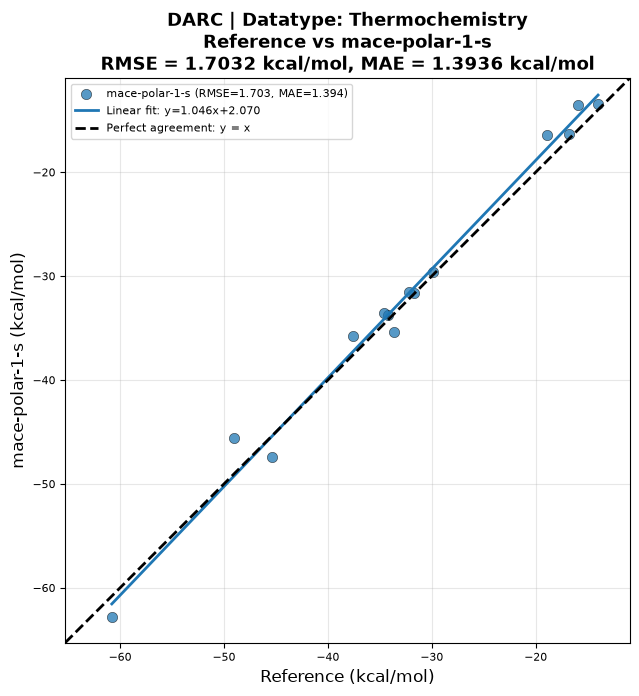


Reference vs MACE-POLAR plot
----------------------------
Dataset: DARC
Datatype: Thermochemistry
Model: mace-polar-1-m
Unit: kcal/mol
Number of points: 14
RMSE: 1.155573 kcal/mol
MAE: 0.965222 kcal/mol
Pearson r: 0.999688
R²: 0.999376
Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\DARC_Reference_vs_mace-polar-1-m.png


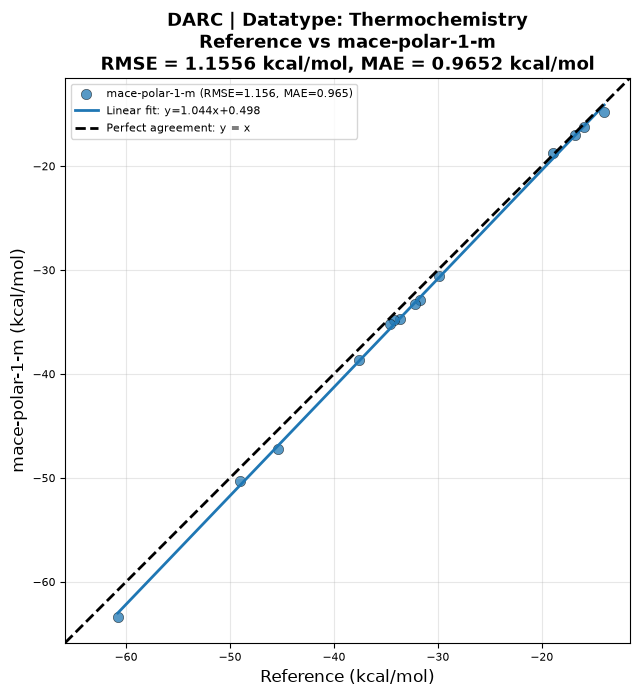


Reference vs MACE-POLAR plot
----------------------------
Dataset: DARC
Datatype: Thermochemistry
Model: mace-polar-1-l
Unit: kcal/mol
Number of points: 14
RMSE: 1.153584 kcal/mol
MAE: 0.984518 kcal/mol
Pearson r: 0.999756
R²: 0.999513
Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\DARC_Reference_vs_mace-polar-1-l.png


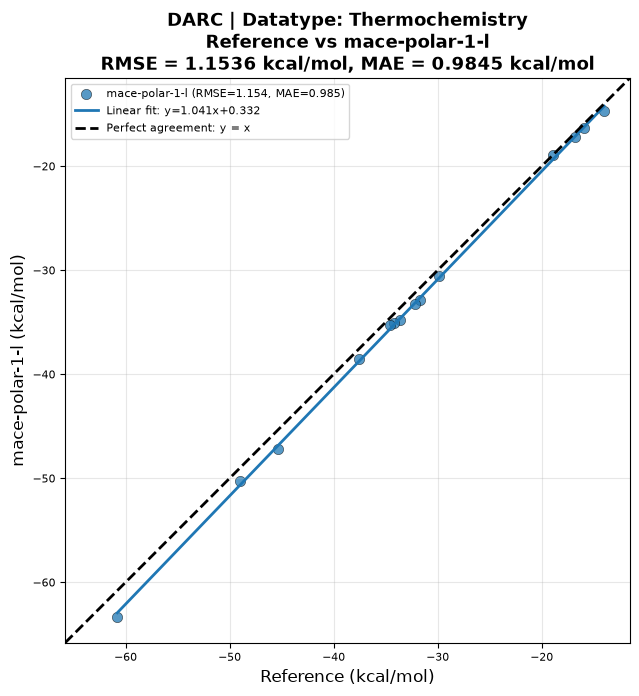


Saved summary to:
C:\Users\91988\GSCDB Benchmarking\Analysis\DARC_Reference_vs_MACE_POLAR_summary.csv

Summary:
  dataset         datatype           model      unit  n_points      rmse  \
0    DARC  Thermochemistry  mace-polar-1-s  kcal/mol        14  1.703215   
1    DARC  Thermochemistry  mace-polar-1-m  kcal/mol        14  1.155573   
2    DARC  Thermochemistry  mace-polar-1-l  kcal/mol        14  1.153584   

        mae  pearson_r  r_squared     slope  intercept  
0  1.393595   0.993949   0.987934  1.046452   2.069694  
1  0.965222   0.999688   0.999376  1.044436   0.497788  
2  0.984518   0.999756   0.999513  1.040541   0.331903  


In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"
figures_dir = analysis_dir / "Figures"
figures_dir.mkdir(exist_ok=True)

dataset_name = "DARC"
unit = "kcal/mol"

input_file = analysis_dir / "Results_values_with_MACE_POLAR_DARC.csv"
datasets_info_file = info_dir / "Datasets.csv"

df = pd.read_csv(input_file, index_col=0)
df_info = pd.read_csv(datasets_info_file)


def get_dataset_info(dataset_name, df_info):
    row = df_info[df_info["Name"] == dataset_name]

    if row.empty:
        datatype = "Unknown"
        description = "No description found"
    else:
        datatype = row["Datatype"].iloc[0]
        description = row["Description"].iloc[0]

    return datatype, description


def calculate_metrics(x, y):
    error = y - x
    absolute_error = np.abs(error)
    squared_error = error ** 2

    rmse = np.sqrt(np.mean(squared_error))
    mae = np.mean(absolute_error)
    pearson_r = np.corrcoef(x, y)[0, 1]

    slope, intercept = np.polyfit(x, y, 1)
    predicted_y = slope * x + intercept

    ss_residual = np.sum((y - predicted_y) ** 2)
    ss_total = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    return {
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r,
        "r_squared": r_squared,
        "slope": slope,
        "intercept": intercept
    }


def plot_reference_vs_single_model(df, dataset_name, model_col):
    datatype, description = get_dataset_info(dataset_name, df_info)

    selected_data = df[df["Dataset"] == dataset_name].copy()

    if selected_data.empty:
        raise ValueError(f"No rows found for Dataset = {dataset_name}")

    required_cols = ["Reference", model_col]

    for col in required_cols:
        if col not in selected_data.columns:
            raise ValueError(f"Column '{col}' not found.")

    x = selected_data["Reference"].to_numpy()
    y = selected_data[model_col].to_numpy()

    metrics = calculate_metrics(x, y)

    min_value = min(x.min(), y.min())
    max_value = max(x.max(), y.max())
    value_range = max_value - min_value

    padding = 0.05 * value_range if value_range > 0 else 1.0
    plot_min = min_value - padding
    plot_max = max_value + padding

    sort_order = np.argsort(x)
    x_sorted = x[sort_order]
    fit_sorted = metrics["slope"] * x_sorted + metrics["intercept"]

    print("\nReference vs MACE-POLAR plot")
    print("----------------------------")
    print(f"Dataset: {dataset_name}")
    print(f"Datatype: {datatype}")
    print(f"Model: {model_col}")
    print(f"Unit: {unit}")
    print(f"Number of points: {len(selected_data)}")
    print(f"RMSE: {metrics['rmse']:.6f} {unit}")
    print(f"MAE: {metrics['mae']:.6f} {unit}")
    print(f"Pearson r: {metrics['pearson_r']:.6f}")
    print(f"R²: {metrics['r_squared']:.6f}")

    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{model_col} (RMSE={metrics['rmse']:.3f}, MAE={metrics['mae']:.3f})"
    )

    plt.plot(
        x_sorted,
        fit_sorted,
        linewidth=2,
        label=f"Linear fit: y={metrics['slope']:.3f}x{metrics['intercept']:+.3f}"
    )

    plt.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
        linewidth=2,
        color="black",
        label="Perfect agreement: y = x"
    )

    plt.xlim(plot_min, plot_max)
    plt.ylim(plot_min, plot_max)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"Reference ({unit})", fontsize=12)
    plt.ylabel(f"{model_col} ({unit})", fontsize=12)

    plt.title(
        f"{dataset_name} | Datatype: {datatype}\n"
        f"Reference vs {model_col}\n"
        f"RMSE = {metrics['rmse']:.4f} {unit}, MAE = {metrics['mae']:.4f} {unit}",
        fontsize=13,
        fontweight="bold"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_plot = figures_dir / f"{dataset_name}_Reference_vs_{model_col}.png"
    plt.savefig(output_plot, dpi=300)

    print("Saved plot to:")
    print(output_plot)

    plt.show()

    result = {
        "dataset": dataset_name,
        "datatype": datatype,
        "model": model_col,
        "unit": unit,
        "n_points": len(selected_data),
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "pearson_r": metrics["pearson_r"],
        "r_squared": metrics["r_squared"],
        "slope": metrics["slope"],
        "intercept": metrics["intercept"],
    }

    return result


mace_models = [
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l"
]

all_results = []

for model_col in mace_models:
    result = plot_reference_vs_single_model(
        df=df,
        dataset_name=dataset_name,
        model_col=model_col
    )

    all_results.append(result)

summary_df = pd.DataFrame(all_results)

summary_file = analysis_dir / f"{dataset_name}_Reference_vs_MACE_POLAR_summary.csv"
summary_df.to_csv(summary_file, index=False)

print("\nSaved summary to:")
print(summary_file)

print("\nSummary:")
print(summary_df)


Combined Reference correlation plot
-----------------------------------
Dataset: DARC
Datatype: Thermochemistry
X-axis: Reference
Y-axis series: wB97M-V and mace-polar-1-s
Unit: kcal/mol
Number of points: 14

wB97M-V:
RMSE: 0.892310 kcal/mol
MAE: 0.706220 kcal/mol
Pearson r: 0.999856
R²: 0.999712

mace-polar-1-s:
RMSE: 1.703215 kcal/mol
MAE: 1.393595 kcal/mol
Pearson r: 0.993949
R²: 0.987934

Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\DARC_Reference_vs_wB97M-V_and_mace-polar-1-s.png


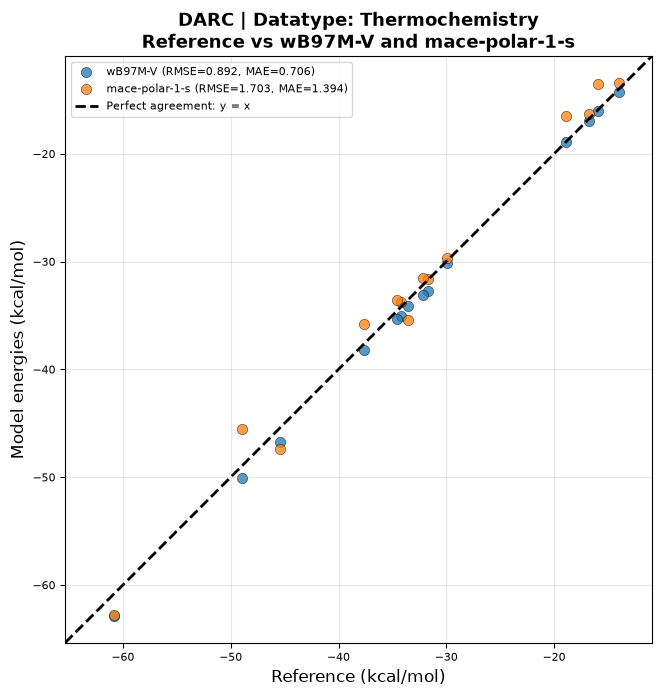


Combined Reference correlation plot
-----------------------------------
Dataset: DARC
Datatype: Thermochemistry
X-axis: Reference
Y-axis series: wB97M-V and mace-polar-1-m
Unit: kcal/mol
Number of points: 14

wB97M-V:
RMSE: 0.892310 kcal/mol
MAE: 0.706220 kcal/mol
Pearson r: 0.999856
R²: 0.999712

mace-polar-1-m:
RMSE: 1.155573 kcal/mol
MAE: 0.965222 kcal/mol
Pearson r: 0.999688
R²: 0.999376

Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\DARC_Reference_vs_wB97M-V_and_mace-polar-1-m.png


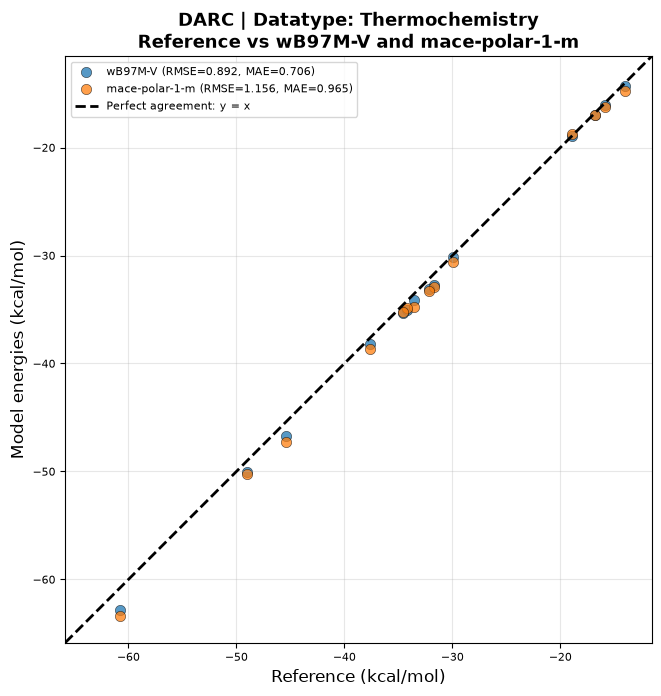


Combined Reference correlation plot
-----------------------------------
Dataset: DARC
Datatype: Thermochemistry
X-axis: Reference
Y-axis series: wB97M-V and mace-polar-1-l
Unit: kcal/mol
Number of points: 14

wB97M-V:
RMSE: 0.892310 kcal/mol
MAE: 0.706220 kcal/mol
Pearson r: 0.999856
R²: 0.999712

mace-polar-1-l:
RMSE: 1.153584 kcal/mol
MAE: 0.984518 kcal/mol
Pearson r: 0.999756
R²: 0.999513

Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\DARC_Reference_vs_wB97M-V_and_mace-polar-1-l.png


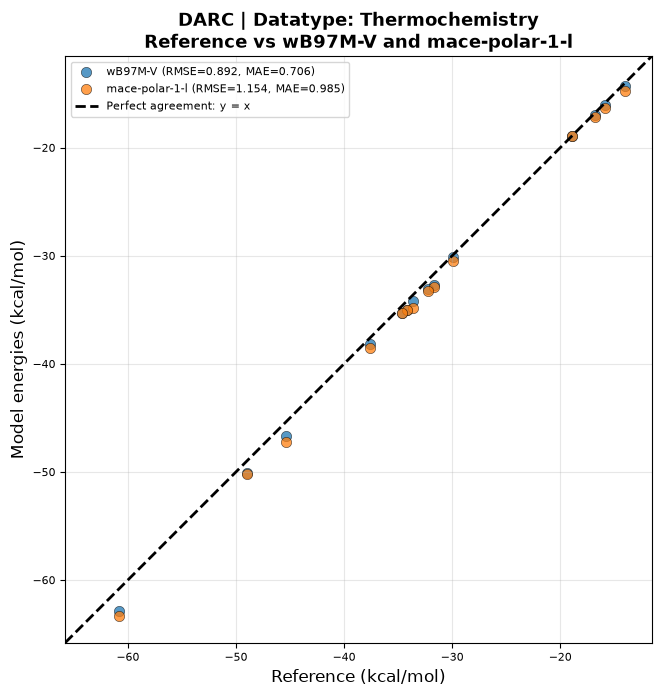


Saved combined summary to:
C:\Users\91988\GSCDB Benchmarking\Analysis\DARC_Reference_vs_wB97MV_and_MACE_summary.csv

Summary:
  dataset         datatype      unit  n_points dft_model  dft_rmse  dft_mae  \
0    DARC  Thermochemistry  kcal/mol        14   wB97M-V   0.89231  0.70622   
1    DARC  Thermochemistry  kcal/mol        14   wB97M-V   0.89231  0.70622   
2    DARC  Thermochemistry  kcal/mol        14   wB97M-V   0.89231  0.70622   

   dft_pearson_r  dft_r_squared      mace_model  mace_rmse  mace_mae  \
0       0.999856       0.999712  mace-polar-1-s   1.703215  1.393595   
1       0.999856       0.999712  mace-polar-1-m   1.155573  0.965222   
2       0.999856       0.999712  mace-polar-1-l   1.153584  0.984518   

   mace_pearson_r  mace_r_squared  
0        0.993949        0.987934  
1        0.999688        0.999376  
2        0.999756        0.999513  


In [12]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"
figures_dir = analysis_dir / "Figures"
figures_dir.mkdir(exist_ok=True)

dataset_name = "DARC"
unit = "kcal/mol"

input_file = analysis_dir / "Results_values_with_MACE_POLAR_DARC.csv"
datasets_info_file = info_dir / "Datasets.csv"

df = pd.read_csv(input_file, index_col=0)
df_info = pd.read_csv(datasets_info_file)


def get_dataset_info(dataset_name, df_info):
    row = df_info[df_info["Name"] == dataset_name]

    if row.empty:
        datatype = "Unknown"
        description = "No description found"
    else:
        datatype = row["Datatype"].iloc[0]
        description = row["Description"].iloc[0]

    return datatype, description


def calculate_metrics(x, y):
    error = y - x
    absolute_error = np.abs(error)
    squared_error = error ** 2

    rmse = np.sqrt(np.mean(squared_error))
    mae = np.mean(absolute_error)
    pearson_r = np.corrcoef(x, y)[0, 1]

    slope, intercept = np.polyfit(x, y, 1)
    predicted_y = slope * x + intercept

    ss_residual = np.sum((y - predicted_y) ** 2)
    ss_total = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    return {
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r,
        "r_squared": r_squared,
        "slope": slope,
        "intercept": intercept
    }


def plot_reference_vs_wb97mv_and_mace(df, dataset_name, mace_col):
    datatype, description = get_dataset_info(dataset_name, df_info)

    selected_data = df[df["Dataset"] == dataset_name].copy()

    if selected_data.empty:
        raise ValueError(f"No rows found for Dataset = {dataset_name}")

    dft_col = "wB97M-V"
    x_col = "Reference"

    required_cols = [x_col, dft_col, mace_col]

    for col in required_cols:
        if col not in selected_data.columns:
            raise ValueError(f"Column '{col}' not found.")

    x = selected_data[x_col].to_numpy()
    y_dft = selected_data[dft_col].to_numpy()
    y_mace = selected_data[mace_col].to_numpy()

    dft_metrics = calculate_metrics(x, y_dft)
    mace_metrics = calculate_metrics(x, y_mace)

    min_value = min(x.min(), y_dft.min(), y_mace.min())
    max_value = max(x.max(), y_dft.max(), y_mace.max())
    value_range = max_value - min_value

    padding = 0.05 * value_range if value_range > 0 else 1.0
    plot_min = min_value - padding
    plot_max = max_value + padding

    print("\nCombined Reference correlation plot")
    print("-----------------------------------")
    print(f"Dataset: {dataset_name}")
    print(f"Datatype: {datatype}")
    print(f"X-axis: {x_col}")
    print(f"Y-axis series: {dft_col} and {mace_col}")
    print(f"Unit: {unit}")
    print(f"Number of points: {len(selected_data)}")

    print(f"\n{dft_col}:")
    print(f"RMSE: {dft_metrics['rmse']:.6f} {unit}")
    print(f"MAE: {dft_metrics['mae']:.6f} {unit}")
    print(f"Pearson r: {dft_metrics['pearson_r']:.6f}")
    print(f"R²: {dft_metrics['r_squared']:.6f}")

    print(f"\n{mace_col}:")
    print(f"RMSE: {mace_metrics['rmse']:.6f} {unit}")
    print(f"MAE: {mace_metrics['mae']:.6f} {unit}")
    print(f"Pearson r: {mace_metrics['pearson_r']:.6f}")
    print(f"R²: {mace_metrics['r_squared']:.6f}")

    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y_dft,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{dft_col} (RMSE={dft_metrics['rmse']:.3f}, MAE={dft_metrics['mae']:.3f})"
    )

    plt.scatter(
        x,
        y_mace,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{mace_col} (RMSE={mace_metrics['rmse']:.3f}, MAE={mace_metrics['mae']:.3f})"
    )

    plt.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
        linewidth=2,
        color="black",
        label="Perfect agreement: y = x"
    )

    plt.xlim(plot_min, plot_max)
    plt.ylim(plot_min, plot_max)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"Reference ({unit})", fontsize=12)
    plt.ylabel(f"Model energies ({unit})", fontsize=12)

    plt.title(
        f"{dataset_name} | Datatype: {datatype}\n"
        f"Reference vs {dft_col} and {mace_col}",
        fontsize=13,
        fontweight="bold"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_plot = figures_dir / f"{dataset_name}_Reference_vs_{dft_col}_and_{mace_col}.png"
    plt.savefig(output_plot, dpi=300)

    print("\nSaved plot to:")
    print(output_plot)

    plt.show()

    result = {
        "dataset": dataset_name,
        "datatype": datatype,
        "unit": unit,
        "n_points": len(selected_data),

        "dft_model": dft_col,
        "dft_rmse": dft_metrics["rmse"],
        "dft_mae": dft_metrics["mae"],
        "dft_pearson_r": dft_metrics["pearson_r"],
        "dft_r_squared": dft_metrics["r_squared"],

        "mace_model": mace_col,
        "mace_rmse": mace_metrics["rmse"],
        "mace_mae": mace_metrics["mae"],
        "mace_pearson_r": mace_metrics["pearson_r"],
        "mace_r_squared": mace_metrics["r_squared"],
    }

    return result


mace_models = [
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l"
]

all_results = []

for mace_col in mace_models:
    result = plot_reference_vs_wb97mv_and_mace(
        df=df,
        dataset_name=dataset_name,
        mace_col=mace_col
    )

    all_results.append(result)

summary_df = pd.DataFrame(all_results)

summary_file = analysis_dir / f"{dataset_name}_Reference_vs_wB97MV_and_MACE_summary.csv"
summary_df.to_csv(summary_file, index=False)

print("\nSaved combined summary to:")
print(summary_file)

print("\nSummary:")
print(summary_df)


Combined Reference correlation plot
-----------------------------------
Dataset: DARC
Datatype: Thermochemistry
X-axis: Reference
Y-axis series: wB97M2 and mace-polar-1-s
Unit: kcal/mol
Number of points: 14

wB97M2:
RMSE: 1.603362 kcal/mol
MAE: 1.530014 kcal/mol
Pearson r: 0.999530
R²: 0.999061

mace-polar-1-s:
RMSE: 1.703215 kcal/mol
MAE: 1.393595 kcal/mol
Pearson r: 0.993949
R²: 0.987934

Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\DARC_Reference_vs_wB97M2_and_mace-polar-1-s.png


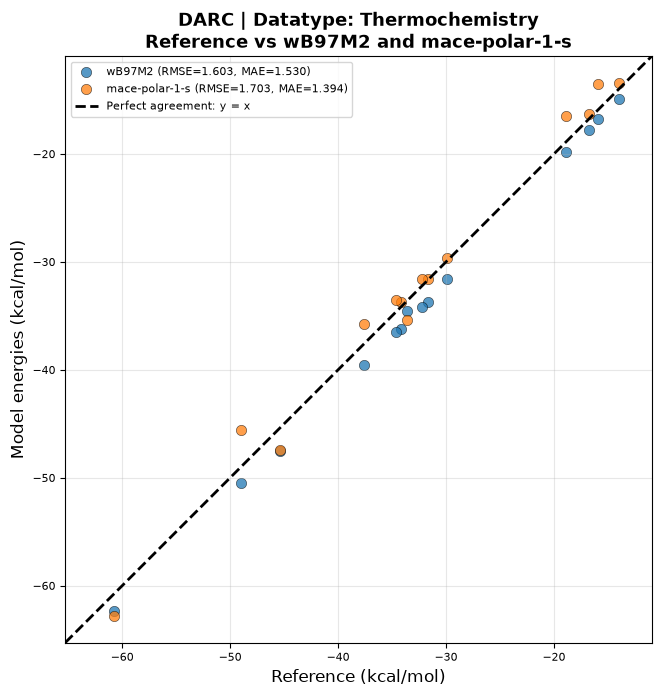


Combined Reference correlation plot
-----------------------------------
Dataset: DARC
Datatype: Thermochemistry
X-axis: Reference
Y-axis series: wB97M2 and mace-polar-1-m
Unit: kcal/mol
Number of points: 14

wB97M2:
RMSE: 1.603362 kcal/mol
MAE: 1.530014 kcal/mol
Pearson r: 0.999530
R²: 0.999061

mace-polar-1-m:
RMSE: 1.155573 kcal/mol
MAE: 0.965222 kcal/mol
Pearson r: 0.999688
R²: 0.999376

Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\DARC_Reference_vs_wB97M2_and_mace-polar-1-m.png


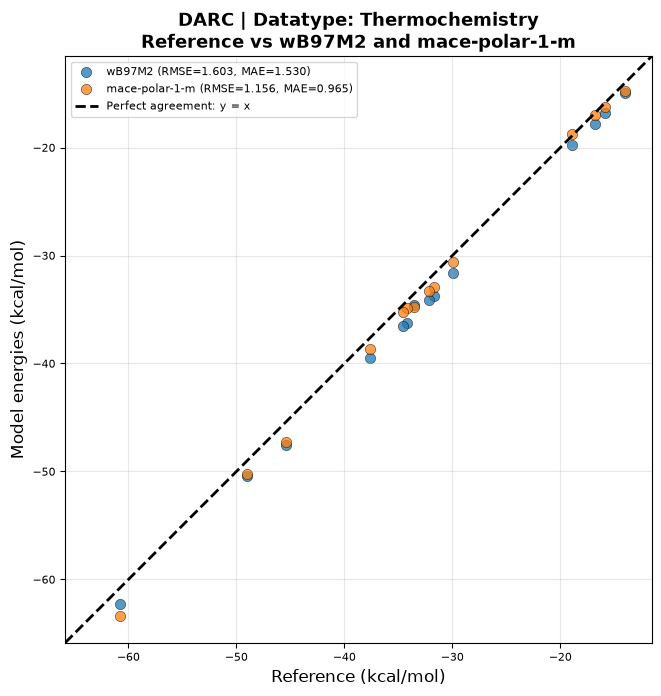


Combined Reference correlation plot
-----------------------------------
Dataset: DARC
Datatype: Thermochemistry
X-axis: Reference
Y-axis series: wB97M2 and mace-polar-1-l
Unit: kcal/mol
Number of points: 14

wB97M2:
RMSE: 1.603362 kcal/mol
MAE: 1.530014 kcal/mol
Pearson r: 0.999530
R²: 0.999061

mace-polar-1-l:
RMSE: 1.153584 kcal/mol
MAE: 0.984518 kcal/mol
Pearson r: 0.999756
R²: 0.999513

Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\DARC_Reference_vs_wB97M2_and_mace-polar-1-l.png


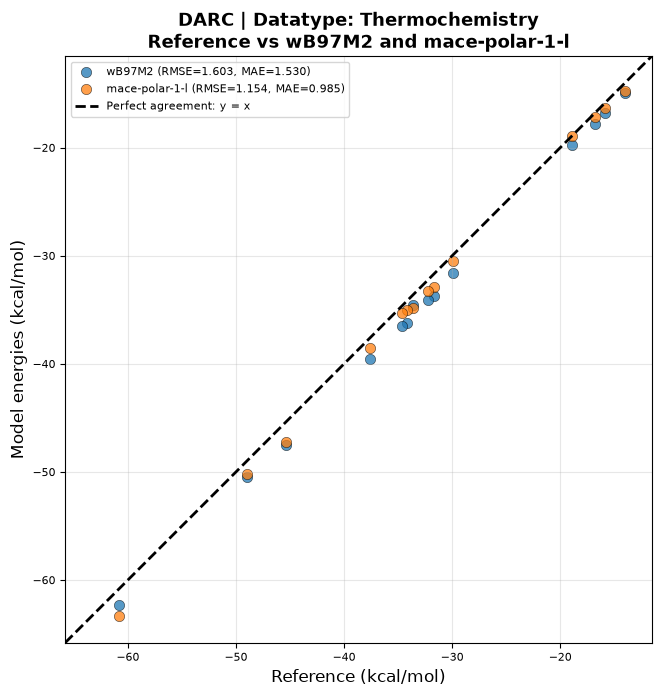


Saved combined summary to:
C:\Users\91988\GSCDB Benchmarking\Analysis\DARC_Reference_vs_wB97M2_and_MACE_summary.csv

Summary:
  dataset         datatype      unit  n_points dft_model  dft_rmse   dft_mae  \
0    DARC  Thermochemistry  kcal/mol        14    wB97M2  1.603362  1.530014   
1    DARC  Thermochemistry  kcal/mol        14    wB97M2  1.603362  1.530014   
2    DARC  Thermochemistry  kcal/mol        14    wB97M2  1.603362  1.530014   

   dft_pearson_r  dft_r_squared      mace_model  mace_rmse  mace_mae  \
0        0.99953       0.999061  mace-polar-1-s   1.703215  1.393595   
1        0.99953       0.999061  mace-polar-1-m   1.155573  0.965222   
2        0.99953       0.999061  mace-polar-1-l   1.153584  0.984518   

   mace_pearson_r  mace_r_squared  
0        0.993949        0.987934  
1        0.999688        0.999376  
2        0.999756        0.999513  


In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"
figures_dir = analysis_dir / "Figures"
figures_dir.mkdir(exist_ok=True)

dataset_name = "DARC"
unit = "kcal/mol"

input_file = analysis_dir / "Results_values_with_MACE_POLAR_DARC.csv"
datasets_info_file = info_dir / "Datasets.csv"

df = pd.read_csv(input_file, index_col=0)
df_info = pd.read_csv(datasets_info_file)


def get_dataset_info(dataset_name, df_info):
    row = df_info[df_info["Name"] == dataset_name]

    if row.empty:
        datatype = "Unknown"
        description = "No description found"
    else:
        datatype = row["Datatype"].iloc[0]
        description = row["Description"].iloc[0]

    return datatype, description


def calculate_metrics(x, y):
    error = y - x
    absolute_error = np.abs(error)
    squared_error = error ** 2

    rmse = np.sqrt(np.mean(squared_error))
    mae = np.mean(absolute_error)
    pearson_r = np.corrcoef(x, y)[0, 1]

    slope, intercept = np.polyfit(x, y, 1)
    predicted_y = slope * x + intercept

    ss_residual = np.sum((y - predicted_y) ** 2)
    ss_total = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    return {
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r,
        "r_squared": r_squared,
        "slope": slope,
        "intercept": intercept
    }


def plot_reference_vs_wB97M2_and_mace(df, dataset_name, mace_col):
    datatype, description = get_dataset_info(dataset_name, df_info)

    selected_data = df[df["Dataset"] == dataset_name].copy()

    if selected_data.empty:
        raise ValueError(f"No rows found for Dataset = {dataset_name}")

    dft_col = "wB97M2"
    x_col = "Reference"

    required_cols = [x_col, dft_col, mace_col]

    for col in required_cols:
        if col not in selected_data.columns:
            raise ValueError(f"Column '{col}' not found.")

    x = selected_data[x_col].to_numpy()
    y_dft = selected_data[dft_col].to_numpy()
    y_mace = selected_data[mace_col].to_numpy()

    dft_metrics = calculate_metrics(x, y_dft)
    mace_metrics = calculate_metrics(x, y_mace)

    min_value = min(x.min(), y_dft.min(), y_mace.min())
    max_value = max(x.max(), y_dft.max(), y_mace.max())
    value_range = max_value - min_value

    padding = 0.05 * value_range if value_range > 0 else 1.0
    plot_min = min_value - padding
    plot_max = max_value + padding

    print("\nCombined Reference correlation plot")
    print("-----------------------------------")
    print(f"Dataset: {dataset_name}")
    print(f"Datatype: {datatype}")
    print(f"X-axis: {x_col}")
    print(f"Y-axis series: {dft_col} and {mace_col}")
    print(f"Unit: {unit}")
    print(f"Number of points: {len(selected_data)}")

    print(f"\n{dft_col}:")
    print(f"RMSE: {dft_metrics['rmse']:.6f} {unit}")
    print(f"MAE: {dft_metrics['mae']:.6f} {unit}")
    print(f"Pearson r: {dft_metrics['pearson_r']:.6f}")
    print(f"R²: {dft_metrics['r_squared']:.6f}")

    print(f"\n{mace_col}:")
    print(f"RMSE: {mace_metrics['rmse']:.6f} {unit}")
    print(f"MAE: {mace_metrics['mae']:.6f} {unit}")
    print(f"Pearson r: {mace_metrics['pearson_r']:.6f}")
    print(f"R²: {mace_metrics['r_squared']:.6f}")

    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y_dft,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{dft_col} (RMSE={dft_metrics['rmse']:.3f}, MAE={dft_metrics['mae']:.3f})"
    )

    plt.scatter(
        x,
        y_mace,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{mace_col} (RMSE={mace_metrics['rmse']:.3f}, MAE={mace_metrics['mae']:.3f})"
    )

    plt.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
        linewidth=2,
        color="black",
        label="Perfect agreement: y = x"
    )

    plt.xlim(plot_min, plot_max)
    plt.ylim(plot_min, plot_max)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"Reference ({unit})", fontsize=12)
    plt.ylabel(f"Model energies ({unit})", fontsize=12)

    plt.title(
        f"{dataset_name} | Datatype: {datatype}\n"
        f"Reference vs {dft_col} and {mace_col}",
        fontsize=13,
        fontweight="bold"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_plot = figures_dir / f"{dataset_name}_Reference_vs_{dft_col}_and_{mace_col}.png"
    plt.savefig(output_plot, dpi=300)

    print("\nSaved plot to:")
    print(output_plot)

    plt.show()

    result = {
        "dataset": dataset_name,
        "datatype": datatype,
        "unit": unit,
        "n_points": len(selected_data),

        "dft_model": dft_col,
        "dft_rmse": dft_metrics["rmse"],
        "dft_mae": dft_metrics["mae"],
        "dft_pearson_r": dft_metrics["pearson_r"],
        "dft_r_squared": dft_metrics["r_squared"],

        "mace_model": mace_col,
        "mace_rmse": mace_metrics["rmse"],
        "mace_mae": mace_metrics["mae"],
        "mace_pearson_r": mace_metrics["pearson_r"],
        "mace_r_squared": mace_metrics["r_squared"],
    }

    return result


mace_models = [
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l"
]

all_results = []

for mace_col in mace_models:
    result = plot_reference_vs_wB97M2_and_mace(
        df=df,
        dataset_name=dataset_name,
        mace_col=mace_col
    )

    all_results.append(result)

summary_df = pd.DataFrame(all_results)

summary_file = analysis_dir / f"{dataset_name}_Reference_vs_wB97M2_and_MACE_summary.csv"
summary_df.to_csv(summary_file, index=False)

print("\nSaved combined summary to:")
print(summary_file)

print("\nSummary:")
print(summary_df)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"
xyz_dir = project_dir / "xyz_files"
qchem_dir = project_dir / "qchem_inputs"

dataset_eval_file = info_dir / "DatasetEval.csv"

output_file = analysis_dir / "Molecule_Energies_MACE_POLAR_BH28.csv"
error_log_file = analysis_dir / "Molecule_Energies_MACE_POLAR_BH28_error_log.csv"

dataset_name = "BH28"

device = "cpu"
default_dtype = "float32"

mace_models = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

# For a faster first test, use only this:
# mace_models = {
#     "mace-polar-1-s": "polar-1-s",
# }


def read_charge_spin_and_field(qchem_file):
    charge = 0
    spin = 1
    external_field = [0.0, 0.0, 0.0]

    if not qchem_file.exists():
        return charge, spin, external_field

    lines = qchem_file.read_text().splitlines()

    for i, line in enumerate(lines):
        if line.strip().lower() == "$molecule":
            charge_spin_line = lines[i + 1].strip().split()
            charge = int(charge_spin_line[0])
            spin = int(charge_spin_line[1])

        if line.strip().lower() == "$multipole_field":
            field_dict = {"X": 0.0, "Y": 0.0, "Z": 0.0}

            j = i + 1
            while j < len(lines) and lines[j].strip().lower() != "$end":
                parts = lines[j].strip().split()

                if len(parts) == 2:
                    axis = parts[0].upper()
                    value = float(parts[1])

                    if axis in field_dict:
                        field_dict[axis] = value

                j += 1

            external_field = [
                field_dict["X"],
                field_dict["Y"],
                field_dict["Z"]
            ]

    return charge, spin, external_field


df_eval = pd.read_csv(dataset_eval_file, index_col=0)

df_dataset = df_eval[df_eval["Dataset"] == dataset_name].copy()

if df_dataset.empty:
    raise ValueError(f"No rows found for Dataset = {dataset_name}")

print(f"Number of {dataset_name} reactions:")
print(len(df_dataset))

all_molecules = set()

for stoich_string in df_dataset["Stoichiometry"].dropna():
    parts = [part.strip() for part in stoich_string.split(",")]

    for i in range(1, len(parts), 2):
        molecule_name = parts[i]
        all_molecules.add(molecule_name)

all_molecules = sorted(all_molecules)

print(f"\nNumber of unique molecules in {dataset_name}:")
print(len(all_molecules))

print("\nFirst 20 molecules:")
print(all_molecules[:20])

if output_file.exists():
    df_mace = pd.read_csv(output_file, index_col=0)
    print("\nExisting molecule energy file found. Already calculated values will be skipped.")
else:
    df_mace = pd.DataFrame(index=all_molecules)

for molecule_name in all_molecules:
    if molecule_name not in df_mace.index:
        df_mace.loc[molecule_name, :] = np.nan

calculators = {}

for output_column, model_name in mace_models.items():
    print(f"\nLoading {output_column} using model = {model_name}")

    calculators[output_column] = mace_polar(
        model=model_name,
        device=device,
        default_dtype=default_dtype
    )

error_log = []

for molecule_name in tqdm(all_molecules, desc=f"Calculating {dataset_name} MACE-POLAR molecular energies"):

    xyz_file = xyz_dir / f"{molecule_name}.xyz"
    qchem_file = qchem_dir / f"{molecule_name}.in"

    if not xyz_file.exists():
        error_log.append({
            "Molecule": molecule_name,
            "Model": "all",
            "Reason": f"Missing xyz file: {xyz_file}"
        })

        for output_column in mace_models:
            df_mace.loc[molecule_name, output_column] = np.nan

        continue

    try:
        charge, spin, external_field = read_charge_spin_and_field(qchem_file)

    except Exception as error:
        error_log.append({
            "Molecule": molecule_name,
            "Model": "all",
            "Reason": f"Failed to parse qchem input: {error}"
        })

        for output_column in mace_models:
            df_mace.loc[molecule_name, output_column] = np.nan

        continue

    try:
        atoms = read(xyz_file)

    except Exception as error:
        error_log.append({
            "Molecule": molecule_name,
            "Model": "all",
            "Reason": f"ASE read failed: {error}"
        })

        for output_column in mace_models:
            df_mace.loc[molecule_name, output_column] = np.nan

        continue

    atoms.info["charge"] = charge
    atoms.info["spin"] = spin
    atoms.info["external_field"] = external_field

    for output_column, calc in calculators.items():

        if output_column in df_mace.columns and pd.notna(df_mace.loc[molecule_name, output_column]):
            continue

        try:
            atoms.calc = calc
            energy_ev = atoms.get_potential_energy()

            df_mace.loc[molecule_name, output_column] = energy_ev

        except Exception as error:
            error_log.append({
                "Molecule": molecule_name,
                "Model": output_column,
                "Reason": str(error)
            })

            df_mace.loc[molecule_name, output_column] = np.nan

    df_mace.index.name = "Molecule"
    df_mace.to_csv(output_file)

df_mace.index.name = "Molecule"
df_mace.to_csv(output_file)

pd.DataFrame(error_log).to_csv(error_log_file, index=False)

print("\nSaved BH28 MACE-POLAR molecular energies to:")
print(output_file)

print("\nSaved error log to:")
print(error_log_file)

print("\nMissing values:")
print(df_mace[list(mace_models.keys())].isna().sum())

c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\e3nn\o3\_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Number of BH28 reactions:
28

Number of unique molecules in BH28:
57

First 20 molecules:
['BH28_BHDIV_1_min', 'BH28_BHDIV_1_ts', 'BH28_BHDIV_2_min', 'BH28_BHDIV_2_ts', 'BH28_BHDIV_3_min', 'BH28_BHDIV_3_ts', 'BH28_BHPERI_1_min', 'BH28_BHPERI_1_ts', 'BH28_BHPERI_2_min', 'BH28_BHPERI_2_ts', 'BH28_BHPERI_3_min', 'BH28_BHPERI_3_ts', 'BH28_BHPERI_4_min', 'BH28_BHPERI_4_ts', 'BH28_BHPERI_5_min', 'BH28_BHPERI_5_ts', 'BH28_BHPERI_6_min', 'BH28_BHPERI_6_ts', 'BH28_CADBH_1_min', 'BH28_CADBH_1_ts']

Existing molecule energy file found. Already calculated values will be skipped.

Loading mace-polar-1-s using model = polar-1-s
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Smodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-m using model = polar-1-m
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-l using model = polar-1-l
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Lmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
Calculating BH28 MACE-POLAR molecular energies: 100%|██████████| 57/57 [00:01<00:00, 32.77it/s]


Saved BH28 MACE-POLAR molecular energies to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_BH28.csv

Saved error log to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_BH28_error_log.csv

Missing values:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64


In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"

dataset_eval_file = info_dir / "DatasetEval.csv"
reaction_energy_file = analysis_dir / "Reaction_Energies.csv"
mace_molecule_file = analysis_dir / "Molecule_Energies_MACE_POLAR_BH28.csv"

output_file = analysis_dir / "Reaction_Energies_with_MACE_POLAR_BH28.csv"

dataset_name = "BH28"

EV_TO_KCAL_PER_MOL = 23.06054783

mace_columns = [
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l",
]

df_eval = pd.read_csv(dataset_eval_file, index_col=0)
df_reaction = pd.read_csv(reaction_energy_file, index_col=0)
df_mace_mol = pd.read_csv(mace_molecule_file, index_col=0)

df_eval_dataset = df_eval[df_eval["Dataset"] == dataset_name].copy()
df_reaction_dataset = df_reaction[df_reaction["Dataset"] == dataset_name].copy()

print(f"Number of {dataset_name} rows in DatasetEval.csv: {len(df_eval_dataset)}")
print(f"Number of {dataset_name} rows in Reaction_Energies.csv: {len(df_reaction_dataset)}")

for idx, row in tqdm(df_eval_dataset.iterrows(), total=len(df_eval_dataset), desc="Calculating BH28 reaction energies"):

    stoich_parts = [part.strip() for part in row["Stoichiometry"].split(",")]

    for mace_col in mace_columns:

        reaction_energy_ev = 0.0
        failed = False

        for i in range(0, len(stoich_parts), 2):
            coefficient = float(stoich_parts[i])
            molecule_name = stoich_parts[i + 1]

            if molecule_name not in df_mace_mol.index:
                print(f"Missing molecule energy: {molecule_name}")
                failed = True
                break

            molecule_energy_ev = df_mace_mol.loc[molecule_name, mace_col]

            if pd.isna(molecule_energy_ev):
                print(f"NaN molecule energy: molecule={molecule_name}, model={mace_col}")
                failed = True
                break

            reaction_energy_ev += coefficient * molecule_energy_ev

        if failed:
            df_reaction.loc[idx, mace_col] = np.nan
        else:
            df_reaction.loc[idx, mace_col] = reaction_energy_ev * EV_TO_KCAL_PER_MOL

df_output = df_reaction[df_reaction["Dataset"] == dataset_name].copy()

df_output.to_csv(output_file)

print("\nSaved BH28 reaction energies with MACE-POLAR to:")
print(output_file)

print("\nMissing values in MACE columns:")
print(df_output[mace_columns].isna().sum())

print("\nFirst rows:")
print(df_output[["Dataset", "Reference", "wB97M-V"] + mace_columns].head())

Number of BH28 rows in DatasetEval.csv: 28
Number of BH28 rows in Reaction_Energies.csv: 28


Calculating BH28 reaction energies: 100%|██████████| 28/28 [00:00<00:00, 367.23it/s]


Saved BH28 reaction energies with MACE-POLAR to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Reaction_Energies_with_MACE_POLAR_BH28.csv

Missing values in MACE columns:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64

First rows:
              Dataset  Reference    wB97M-V  mace-polar-1-s  mace-polar-1-m  \
Reaction                                                                      
BH28_BHDIV_1     BH28  56.955067  56.864131       59.329115       57.020808   
BH28_BHDIV_2     BH28  50.095602  50.716834       50.782749       50.287308   
BH28_BHDIV_3     BH28  65.559273  63.827054       68.370921       65.758593   
BH28_BHPERI_4    BH28  35.014340  36.690550       43.227267       37.777411   
BH28_BHPERI_5    BH28  30.999044  30.477149       34.151680       30.672330   

               mace-polar-1-l  
Reaction                       
BH28_BHDIV_1        58.405792  
BH28_BHDIV_2        50.670149  
BH28_BHDIV_3        64.362349  
BH28_BHPERI_4       36.516287  

In [19]:
from pathlib import Path
import pandas as pd

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"

input_file = analysis_dir / "Reaction_Energies_with_MACE_POLAR_BH28.csv"
output_values_file = analysis_dir / "Results_values_with_MACE_POLAR_BH28.csv"
output_errors_file = analysis_dir / "Results_errors_with_MACE_POLAR_BH28.csv"

df_values = pd.read_csv(input_file, index_col=0)

metadata_cols = ["Reaction", "Dataset"]
value_cols = [col for col in df_values.columns if col not in metadata_cols]

df_errors = df_values.copy()

for col in value_cols:
    if col != "Reference":
        df_errors[col] = df_values[col] - df_values["Reference"]

df_values.to_csv(output_values_file)
df_errors.to_csv(output_errors_file)

print("Saved BH28 results values to:")
print(output_values_file)

print("\nSaved BH28 results errors to:")
print(output_errors_file)

print("\nColumns:")
print(df_values.columns.tolist())

Saved BH28 results values to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Results_values_with_MACE_POLAR_BH28.csv

Saved BH28 results errors to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Results_errors_with_MACE_POLAR_BH28.csv

Columns:
['Dataset', 'Reference', 'wB97M2', 'B3LYP', 'BMK', 'CAMB3LYP', 'CF22D', 'M052X', 'M062X', 'M08HX', 'MN15', 'PBE0', 'PW6B95', 'SOGGA11X', 'r2SCAN0', 'wB97M-V', 'wB97X-V', 'revDSD-PBEP86-D4', 'mace-polar-1-s', 'mace-polar-1-m', 'mace-polar-1-l']



Combined Reference correlation plot
-----------------------------------
Dataset: BH28
Datatype: Barrier Height
X-axis: Reference
Y-axis series: wB97M-V and mace-polar-1-s
Unit: kcal/mol
Number of points: 28

wB97M-V:
RMSE: 1.285163 kcal/mol
MAE: 0.985091 kcal/mol
Pearson r: 0.997369
R²: 0.994744

mace-polar-1-s:
RMSE: 4.477151 kcal/mol
MAE: 3.672297 kcal/mol
Pearson r: 0.970572
R²: 0.942009

Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\BH28_Reference_vs_wB97M-V_and_mace-polar-1-s.png


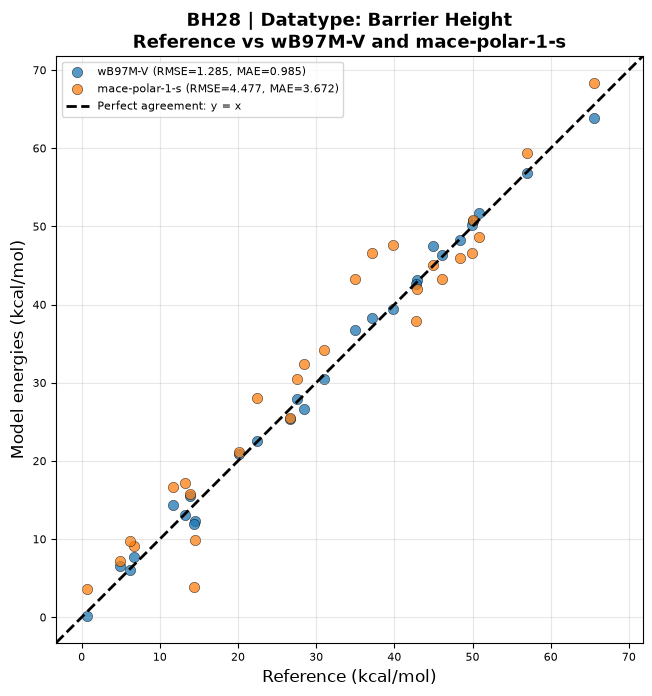


Combined Reference correlation plot
-----------------------------------
Dataset: BH28
Datatype: Barrier Height
X-axis: Reference
Y-axis series: wB97M-V and mace-polar-1-m
Unit: kcal/mol
Number of points: 28

wB97M-V:
RMSE: 1.285163 kcal/mol
MAE: 0.985091 kcal/mol
Pearson r: 0.997369
R²: 0.994744

mace-polar-1-m:
RMSE: 1.809502 kcal/mol
MAE: 1.360397 kcal/mol
Pearson r: 0.995377
R²: 0.990775

Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\BH28_Reference_vs_wB97M-V_and_mace-polar-1-m.png


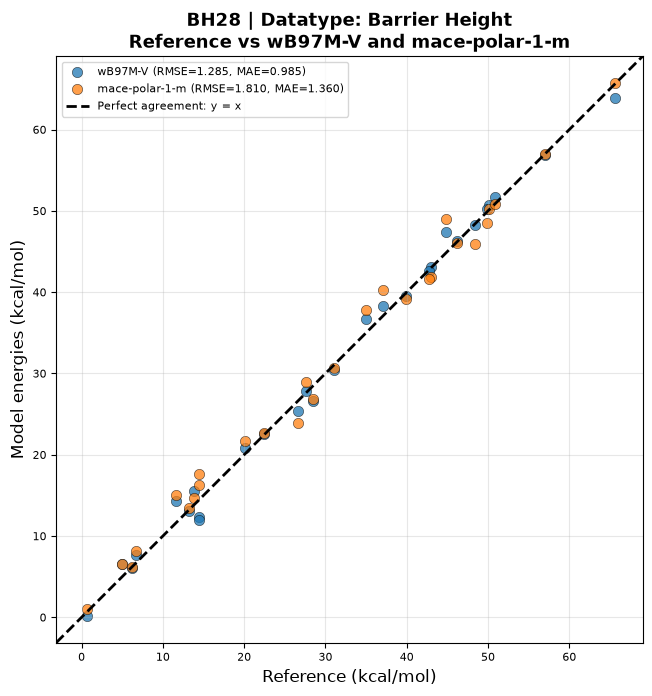


Combined Reference correlation plot
-----------------------------------
Dataset: BH28
Datatype: Barrier Height
X-axis: Reference
Y-axis series: wB97M-V and mace-polar-1-l
Unit: kcal/mol
Number of points: 28

wB97M-V:
RMSE: 1.285163 kcal/mol
MAE: 0.985091 kcal/mol
Pearson r: 0.997369
R²: 0.994744

mace-polar-1-l:
RMSE: 1.315516 kcal/mol
MAE: 1.102822 kcal/mol
Pearson r: 0.997329
R²: 0.994665

Saved plot to:
C:\Users\91988\GSCDB Benchmarking\Analysis\Figures\BH28_Reference_vs_wB97M-V_and_mace-polar-1-l.png


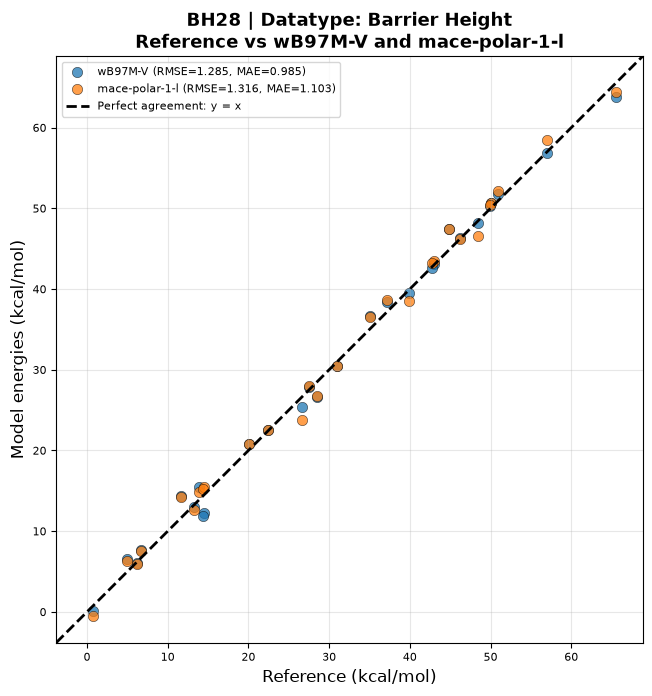


Saved combined summary to:
C:\Users\91988\GSCDB Benchmarking\Analysis\BH28_Reference_vs_wB97MV_and_MACE_summary.csv

Summary:
  dataset        datatype      unit  n_points dft_model  dft_rmse   dft_mae  \
0    BH28  Barrier Height  kcal/mol        28   wB97M-V  1.285163  0.985091   
1    BH28  Barrier Height  kcal/mol        28   wB97M-V  1.285163  0.985091   
2    BH28  Barrier Height  kcal/mol        28   wB97M-V  1.285163  0.985091   

   dft_pearson_r  dft_r_squared      mace_model  mace_rmse  mace_mae  \
0       0.997369       0.994744  mace-polar-1-s   4.477151  3.672297   
1       0.997369       0.994744  mace-polar-1-m   1.809502  1.360397   
2       0.997369       0.994744  mace-polar-1-l   1.315516  1.102822   

   mace_pearson_r  mace_r_squared  
0        0.970572        0.942009  
1        0.995377        0.990775  
2        0.997329        0.994665  


In [20]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_dir = Path("MACE-POLAR Calculations.ipynb").resolve().parents[1]

analysis_dir = project_dir / "Analysis"
info_dir = project_dir / "Info"
figures_dir = analysis_dir / "Figures"
figures_dir.mkdir(exist_ok=True)

dataset_name = "BH28"
unit = "kcal/mol"

input_file = analysis_dir / "Results_values_with_MACE_POLAR_BH28.csv"
datasets_info_file = info_dir / "Datasets.csv"

df = pd.read_csv(input_file, index_col=0)
df_info = pd.read_csv(datasets_info_file)


def get_dataset_info(dataset_name, df_info):
    row = df_info[df_info["Name"] == dataset_name]

    if row.empty:
        datatype = "Unknown"
        description = "No description found"
    else:
        datatype = row["Datatype"].iloc[0]
        description = row["Description"].iloc[0]

    return datatype, description


def calculate_metrics(x, y):
    error = y - x
    absolute_error = np.abs(error)
    squared_error = error ** 2

    rmse = np.sqrt(np.mean(squared_error))
    mae = np.mean(absolute_error)
    pearson_r = np.corrcoef(x, y)[0, 1]

    slope, intercept = np.polyfit(x, y, 1)
    predicted_y = slope * x + intercept

    ss_residual = np.sum((y - predicted_y) ** 2)
    ss_total = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    return {
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r,
        "r_squared": r_squared,
        "slope": slope,
        "intercept": intercept
    }


def plot_reference_vs_wb97mv_and_mace(df, dataset_name, mace_col):
    datatype, description = get_dataset_info(dataset_name, df_info)

    selected_data = df[df["Dataset"] == dataset_name].copy()

    if selected_data.empty:
        raise ValueError(f"No rows found for Dataset = {dataset_name}")

    dft_col = "wB97M-V"
    x_col = "Reference"

    required_cols = [x_col, dft_col, mace_col]

    for col in required_cols:
        if col not in selected_data.columns:
            raise ValueError(f"Column '{col}' not found.")

    x = selected_data[x_col].to_numpy()
    y_dft = selected_data[dft_col].to_numpy()
    y_mace = selected_data[mace_col].to_numpy()

    dft_metrics = calculate_metrics(x, y_dft)
    mace_metrics = calculate_metrics(x, y_mace)

    min_value = min(x.min(), y_dft.min(), y_mace.min())
    max_value = max(x.max(), y_dft.max(), y_mace.max())
    value_range = max_value - min_value

    padding = 0.05 * value_range if value_range > 0 else 1.0
    plot_min = min_value - padding
    plot_max = max_value + padding

    print("\nCombined Reference correlation plot")
    print("-----------------------------------")
    print(f"Dataset: {dataset_name}")
    print(f"Datatype: {datatype}")
    print(f"X-axis: {x_col}")
    print(f"Y-axis series: {dft_col} and {mace_col}")
    print(f"Unit: {unit}")
    print(f"Number of points: {len(selected_data)}")

    print(f"\n{dft_col}:")
    print(f"RMSE: {dft_metrics['rmse']:.6f} {unit}")
    print(f"MAE: {dft_metrics['mae']:.6f} {unit}")
    print(f"Pearson r: {dft_metrics['pearson_r']:.6f}")
    print(f"R²: {dft_metrics['r_squared']:.6f}")

    print(f"\n{mace_col}:")
    print(f"RMSE: {mace_metrics['rmse']:.6f} {unit}")
    print(f"MAE: {mace_metrics['mae']:.6f} {unit}")
    print(f"Pearson r: {mace_metrics['pearson_r']:.6f}")
    print(f"R²: {mace_metrics['r_squared']:.6f}")

    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y_dft,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{dft_col} (RMSE={dft_metrics['rmse']:.3f}, MAE={dft_metrics['mae']:.3f})"
    )

    plt.scatter(
        x,
        y_mace,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{mace_col} (RMSE={mace_metrics['rmse']:.3f}, MAE={mace_metrics['mae']:.3f})"
    )

    plt.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
        linewidth=2,
        color="black",
        label="Perfect agreement: y = x"
    )

    plt.xlim(plot_min, plot_max)
    plt.ylim(plot_min, plot_max)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"Reference ({unit})", fontsize=12)
    plt.ylabel(f"Model energies ({unit})", fontsize=12)

    plt.title(
        f"{dataset_name} | Datatype: {datatype}\n"
        f"Reference vs {dft_col} and {mace_col}",
        fontsize=13,
        fontweight="bold"
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_plot = figures_dir / f"{dataset_name}_Reference_vs_{dft_col}_and_{mace_col}.png"
    plt.savefig(output_plot, dpi=300)

    print("\nSaved plot to:")
    print(output_plot)

    plt.show()

    result = {
        "dataset": dataset_name,
        "datatype": datatype,
        "unit": unit,
        "n_points": len(selected_data),

        "dft_model": dft_col,
        "dft_rmse": dft_metrics["rmse"],
        "dft_mae": dft_metrics["mae"],
        "dft_pearson_r": dft_metrics["pearson_r"],
        "dft_r_squared": dft_metrics["r_squared"],

        "mace_model": mace_col,
        "mace_rmse": mace_metrics["rmse"],
        "mace_mae": mace_metrics["mae"],
        "mace_pearson_r": mace_metrics["pearson_r"],
        "mace_r_squared": mace_metrics["r_squared"],
    }

    return result


mace_models = [
    "mace-polar-1-s",
    "mace-polar-1-m",
    "mace-polar-1-l"
]

all_results = []

for mace_col in mace_models:
    result = plot_reference_vs_wb97mv_and_mace(
        df=df,
        dataset_name=dataset_name,
        mace_col=mace_col
    )

    all_results.append(result)

summary_df = pd.DataFrame(all_results)

summary_file = analysis_dir / f"{dataset_name}_Reference_vs_wB97MV_and_MACE_summary.csv"
summary_df.to_csv(summary_file, index=False)

print("\nSaved combined summary to:")
print(summary_file)

print("\nSummary:")
print(summary_df)

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
from ase.io import read
from mace.calculators import mace_polar

# -----------------------------
# Find correct GSCDB project folder
# -----------------------------
def find_gscdb_root():
    current = Path.cwd()

    # Case 1: notebook is already in GSCDB root
    if (current / "xyz_files").exists() and (current / "Info").exists():
        return current

    # Case 2: notebook is inside Analysis folder
    if (current.parent / "xyz_files").exists() and (current.parent / "Info").exists():
        return current.parent

    raise FileNotFoundError(
        "Could not find GSCDB root folder containing xyz_files and Info."
    )

project_dir = find_gscdb_root()

xyz_dir = project_dir / "xyz_files"
info_dir = project_dir / "Info"

print("Project folder:")
print(project_dir)

print("\nxyz_files folder:")
print(xyz_dir)

print("\nxyz_files exists?")
print(xyz_dir.exists())

# -----------------------------
# Pick one actual Dip146 molecule from DatasetEval.csv
# -----------------------------
df_eval = pd.read_csv(info_dir / "DatasetEval.csv", index_col=0)
df_dip146 = df_eval[df_eval["Dataset"] == "Dip146"].copy()

first_stoich = df_dip146["Stoichiometry"].iloc[0]
parts = [p.strip() for p in first_stoich.split(",")]

molecule_name = parts[1]

xyz_file = xyz_dir / f"{molecule_name}.xyz"

print("\nTesting molecule:")
print(molecule_name)

print("\nXYZ file:")
print(xyz_file)

print("\nXYZ exists?")
print(xyz_file.exists())

if not xyz_file.exists():
    raise FileNotFoundError(f"XYZ file not found: {xyz_file}")

# -----------------------------
# Load MACE-POLAR model
# -----------------------------
calc = mace_polar(
    model="polar-1-m",
    device="cpu",
    default_dtype="float64"
)

def force_fresh_calculation(calc):
    if hasattr(calc, "reset"):
        calc.reset()
    else:
        calc.results = {}
        if hasattr(calc, "atoms"):
            calc.atoms = None

def get_energy_with_field(field_v_per_angstrom):
    atoms = read(xyz_file)

    # Re-centre to centroid
    atoms.positions -= np.mean(atoms.positions, axis=0)

    atoms.info["charge"] = 0
    atoms.info["spin"] = 1
    atoms.info["external_field"] = np.array(
        [0.0, 0.0, field_v_per_angstrom],
        dtype=float
    )

    force_fresh_calculation(calc)

    atoms.calc = calc
    energy = float(atoms.get_potential_energy())

    return energy

# -----------------------------
# Test different external fields
# -----------------------------
e_zero = get_energy_with_field(0.0)
e_plus = get_energy_with_field(0.001)
e_minus = get_energy_with_field(-0.001)

print("\nEnergy test:")
print("E(0)       =", e_zero)
print("E(+field)  =", e_plus)
print("E(-field)  =", e_minus)
print("E(+)-E(-)  =", e_plus - e_minus)

Project folder:
c:\Users\91988\GSCDB Benchmarking

xyz_files folder:
c:\Users\91988\GSCDB Benchmarking\xyz_files

xyz_files exists?
True

Testing molecule:
Dip146_AlF2+

XYZ file:
c:\Users\91988\GSCDB Benchmarking\xyz_files\Dip146_AlF2+.xyz

XYZ exists?
True
Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Energy test:
E(0)       = -9315.835157189402
E(+field)  = -9315.835237423324
E(-field)  = -9315.835077215426
E(+)-E(-)  = -0.0001602078973519383


In [4]:
from pathlib import Path
import numpy as np
from ase.io import read
from mace.calculators import mace_polar

project_dir = Path.cwd()

if not (project_dir / "xyz_files").exists():
    project_dir = project_dir.parent

xyz_dir = project_dir / "xyz_files"

FIELD_AU_TO_VA = 51.4220674763
EV_TO_KCAL_PER_MOL = 23.06054783

calc = mace_polar(
    model="polar-1-m",
    device="cpu",
    default_dtype="float64"
)

def force_fresh_calculation(calc):
    try:
        calc.reset()
    except Exception:
        pass

    try:
        calc.results = {}
    except Exception:
        pass

    try:
        calc.atoms = None
    except Exception:
        pass

def get_dip146_energy(molecule_name, field_au_z):
    xyz_file = xyz_dir / f"{molecule_name}.xyz"

    atoms = read(xyz_file)

    atoms.positions -= np.mean(atoms.positions, axis=0)

    atoms.info["charge"] = 0
    atoms.info["spin"] = 1
    atoms.info["external_field"] = np.array(
        [0.0, 0.0, field_au_z * FIELD_AU_TO_VA],
        dtype=float
    )

    force_fresh_calculation(calc)

    atoms.calc = calc

    return float(atoms.get_potential_energy())

e_plus = get_dip146_energy("Dip146_AlF2+", 0.0001)
e_minus = get_dip146_energy("Dip146_AlF2-", -0.0001)

reaction_energy_ev = e_plus - e_minus
reaction_energy_kcal = reaction_energy_ev * EV_TO_KCAL_PER_MOL

print("E(+field) eV =", e_plus)
print("E(-field) eV =", e_minus)
print("E(+)-E(-) eV =", reaction_energy_ev)
print("Reaction finite-difference energy kcal/mol =", reaction_energy_kcal)

Using MACE-Polar model for MACECalculator with C:\Users\91988\.cache\mace/MACEPOLAR1Mmodel


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


E(+field) eV = -9315.835572733808
E(-field) eV = -9315.83474885514
E(+)-E(-) eV = -0.00082387866677891
Reaction finite-difference energy kcal/mol = -0.018999093401371688


Project folder:
c:\Users\91988\GSCDB Benchmarking

Device selected:
cpu

Model:
mace-polar-1-l -> polar-1-l

Loading GSCDB files...

Dataset information
-------------------
Dataset: Dip146
Datatype: Electric field
Description: Dipole moments (including individual components) for 146 small systems at equilibrium
Rows in Dip146: 190

Validation using existing GSCDB Results_values.csv
--------------------------------------------------
wB97M-V MAE  = 0.057971 D
wB97M-V RMSE = 0.109842 D
Expected paper wB97M-V MAE ≈ 0.058 D

Unique Dip146 molecules:
380

First 20 molecules:
['Dip146_AlF2+', 'Dip146_AlF2-', 'Dip146_AlH22+', 'Dip146_AlH22-', 'Dip146_BF2+', 'Dip146_BF2-', 'Dip146_BH2+', 'Dip146_BH2-', 'Dip146_BH22+', 'Dip146_BH22-', 'Dip146_BH2Cl2+', 'Dip146_BH2Cl2-', 'Dip146_BH2F2+', 'Dip146_BH2F2-', 'Dip146_BHCl22+', 'Dip146_BHCl22-', 'Dip146_BHF22+', 'Dip146_BHF22-', 'Dip146_BN2+', 'Dip146_BN2-']

File check
----------
Missing xyz files: 0
Missing qchem input files: 0

External field previe

c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-l: molecular energies: 100%|██████████| 380/380 [07:46<00:00,  1.23s/it]



Saved molecule energies to:
c:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_Dip146_L_ONLY.csv

Saved error log to:
c:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_Dip146_L_ONLY_error_log.csv

Missing molecule energies:
0

Molecule-energy field check:
                field_au_x  field_au_y  field_au_z  field_VA_x  field_VA_y  \
Molecule                                                                     
Dip146_AlF2+           0.0         0.0      0.0001         0.0         0.0   
Dip146_AlF2-           0.0         0.0     -0.0001         0.0         0.0   
Dip146_AlH22+          0.0         0.0      0.0001         0.0         0.0   
Dip146_AlH22-          0.0         0.0     -0.0001         0.0         0.0   
Dip146_BF2+            0.0         0.0      0.0001         0.0         0.0   
Dip146_BF2-            0.0         0.0     -0.0001         0.0         0.0   
Dip146_BH2+            0.0         0.0      0.0001         0.0         0.0  

Dip146 reaction energies: 100%|██████████| 190/190 [00:00<00:00, 1606.80it/s]


Saved reaction finite-difference energies to:
c:\Users\91988\GSCDB Benchmarking\Analysis\Reaction_Energies_with_MACE_POLAR_Dip146_L_ONLY.csv

Reaction-energy sanity check:
       mace-polar-1-l
count      190.000000
mean        -0.009274
std          0.121550
min         -0.444545
25%         -0.063999
50%          0.012710
75%          0.066549
max          0.331879

Exact zeros:
0

Unique values:
190

First rows before Debye conversion:
         Dataset  Reference   wB97M-V  mace-polar-1-l
Reaction                                             
Dip146_1  Dip146  -0.072731 -0.076598       -0.073918
Dip146_2  Dip146  -0.019806 -0.025384       -0.016645
Dip146_3  Dip146   0.011451  0.016685        0.014978
Dip146_4  Dip146   0.040462  0.045455        0.045811
Dip146_5  Dip146   0.069640  0.074979        0.065256

Inferred Dip146 conversion scale
--------------------------------
Scale factor: 20.252650398685
Ratio standard deviation: 2.946462934546e-15
Number of points used: 190



Saved Results_values file:
c:\Users\91988\GSCDB Benchmarking\Analysis\Results_values_with_MACE_POLAR_Dip146_L_ONLY.csv

Saved Results_errors file:
c:\Users\91988\GSCDB Benchmarking\Analysis\Results_errors_with_MACE_POLAR_Dip146_L_ONLY.csv

First rows after Debye conversion:
         Dataset  Reference   wB97M-V  mace-polar-1-l
Reaction                                             
Dip146_1  Dip146  -1.472993 -1.551306       -1.497029
Dip146_2  Dip146  -0.401126 -0.514087       -0.337103
Dip146_3  Dip146   0.231915  0.337914        0.303348
Dip146_4  Dip146   0.819454  0.920576        0.927784
Dip146_5  Dip146   1.410389  1.518527        1.321607

Metric table:
  Dataset        Datatype           Model Unit    N      RMSE       MAE  \
0  Dip146  Electric field         wB97M-V    D  190  0.109842  0.057971   
1  Dip146  Electric field  mace-polar-1-l    D  190  0.300921  0.173650   

   Pearson_r  R_squared     Slope  Intercept  
0   0.999008   0.998017  0.993913  -0.006087  
1   0.99251

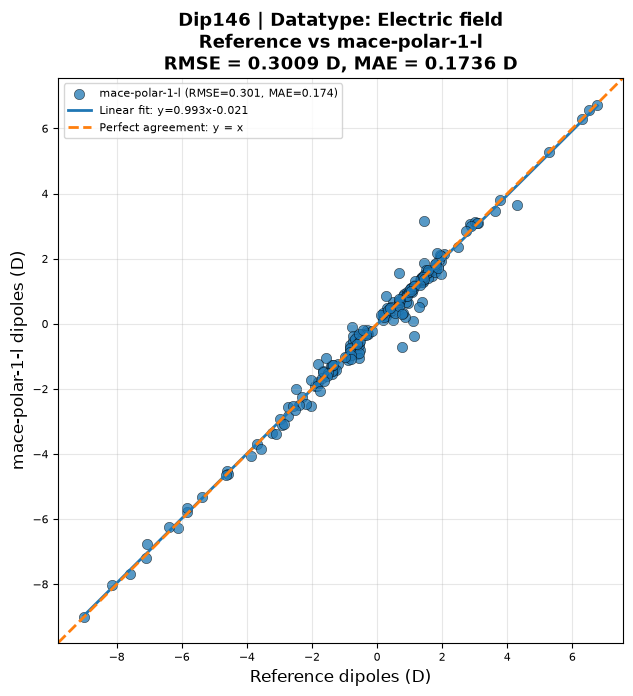


Saved plot:
c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Dip146_Reference_vs_mace-polar-1-l_L_ONLY.png


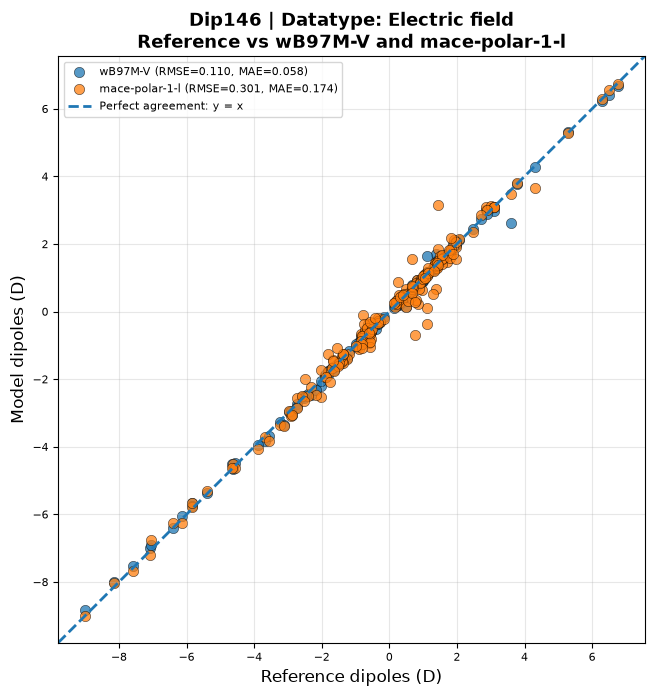


Saved combined plot:
c:\Users\91988\GSCDB Benchmarking\Analysis\Figures\Dip146_Reference_vs_wB97M-V_and_mace-polar-1-l_L_ONLY.png

Saved MACE-only summary:
c:\Users\91988\GSCDB Benchmarking\Analysis\Dip146_Reference_vs_mace_polar_1_l_summary.csv

Saved combined summary:
c:\Users\91988\GSCDB Benchmarking\Analysis\Dip146_Reference_vs_wB97MV_and_mace_polar_1_l_summary.csv

Dip146 polar-1-l workflow finished.

Generated files:
c:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_Dip146_L_ONLY.csv
c:\Users\91988\GSCDB Benchmarking\Analysis\Molecule_Energies_MACE_POLAR_Dip146_L_ONLY_error_log.csv
c:\Users\91988\GSCDB Benchmarking\Analysis\Reaction_Energies_with_MACE_POLAR_Dip146_L_ONLY.csv
c:\Users\91988\GSCDB Benchmarking\Analysis\Results_values_with_MACE_POLAR_Dip146_L_ONLY.csv
c:\Users\91988\GSCDB Benchmarking\Analysis\Results_errors_with_MACE_POLAR_Dip146_L_ONLY.csv
c:\Users\91988\GSCDB Benchmarking\Analysis\Dip146_mace_polar_1_l_metrics.csv
c:\Users\91988\GSCDB Bench

In [6]:
# ============================================================
# FULL CORRECTED Dip146 WORKFLOW
# ONLY MODEL: mace-polar-1-l / polar-1-l
# ============================================================

from pathlib import Path
import re
import ast
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

try:
    import torch
except Exception:
    torch = None


# ============================================================
# 1. SETTINGS
# ============================================================

DATASET_NAME = "Dip146"
UNIT = "D"  # Debye

MODEL_COL = "mace-polar-1-l"
MODEL_NAME = "polar-1-l"

DEFAULT_DTYPE = "float64"

if torch is not None and torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

EV_TO_KCAL_PER_MOL = 23.06054783

# atomic unit of electric field -> V/Å
FIELD_AU_TO_VA = 51.4220674763


# ============================================================
# 2. FIND PROJECT DIRECTORY
# ============================================================

def find_project_dir():
    current = Path.cwd()

    required_folders = ["Analysis", "Info", "xyz_files", "qchem_inputs"]

    if all((current / folder).exists() for folder in required_folders):
        return current

    if all((current.parent / folder).exists() for folder in required_folders):
        return current.parent

    raise FileNotFoundError(
        "Could not find GSCDB project folder. "
        "Run this notebook from the folder containing Analysis, Info, xyz_files, and qchem_inputs."
    )


PROJECT_DIR = find_project_dir()

analysis_dir = PROJECT_DIR / "Analysis"
info_dir = PROJECT_DIR / "Info"
xyz_dir = PROJECT_DIR / "xyz_files"
qchem_dir = PROJECT_DIR / "qchem_inputs"
figures_dir = analysis_dir / "Figures"

figures_dir.mkdir(exist_ok=True)

dataset_eval_file = info_dir / "DatasetEval.csv"
datasets_info_file = info_dir / "Datasets.csv"
reaction_energy_file = analysis_dir / "Reaction_Energies.csv"
results_values_file = analysis_dir / "Results_values.csv"

# Use L_ONLY file names so old all-zero files are not reused
molecule_energy_file = analysis_dir / "Molecule_Energies_MACE_POLAR_Dip146_L_ONLY.csv"
molecule_error_log_file = analysis_dir / "Molecule_Energies_MACE_POLAR_Dip146_L_ONLY_error_log.csv"

reaction_output_file = analysis_dir / "Reaction_Energies_with_MACE_POLAR_Dip146_L_ONLY.csv"
results_values_output_file = analysis_dir / "Results_values_with_MACE_POLAR_Dip146_L_ONLY.csv"
results_errors_output_file = analysis_dir / "Results_errors_with_MACE_POLAR_Dip146_L_ONLY.csv"

metric_table_file = analysis_dir / "Dip146_mace_polar_1_l_metrics.csv"
mace_only_summary_file = analysis_dir / "Dip146_Reference_vs_mace_polar_1_l_summary.csv"
combined_summary_file = analysis_dir / "Dip146_Reference_vs_wB97MV_and_mace_polar_1_l_summary.csv"

print("Project folder:")
print(PROJECT_DIR)

print("\nDevice selected:")
print(DEVICE)

print("\nModel:")
print(MODEL_COL, "->", MODEL_NAME)


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def force_fresh_calculation(calc):
    """
    Very important for Dip146.

    Dip146 +field and -field files can have identical coordinates.
    Only external_field changes. So we must clear calculator cache
    before every atoms.get_potential_energy() call.
    """
    try:
        calc.reset()
    except Exception:
        pass

    try:
        calc.results = {}
    except Exception:
        pass

    try:
        calc.atoms = None
    except Exception:
        pass


def get_dataset_info(dataset_name, df_info):
    row = df_info[df_info["Name"] == dataset_name]

    if row.empty:
        return "Unknown", "No description found"

    return row["Datatype"].iloc[0], row["Description"].iloc[0]


def read_qchem_charge_multiplicity_and_field(qchem_file):
    """
    Preferred source for Dip146 external field.

    Reads:
        $molecule
        charge multiplicity
        ...
        $end

        $multipole_field
        X ...
        Y ...
        Z ...
        $end

    Returns:
        charge
        multiplicity
        field_au as np.array([Fx, Fy, Fz])
    """
    charge = 0
    multiplicity = 1
    field_au = np.array([0.0, 0.0, 0.0], dtype=float)

    if not qchem_file.exists():
        return charge, multiplicity, field_au

    lines = qchem_file.read_text(errors="ignore").splitlines()

    for i, line in enumerate(lines):
        stripped = line.strip().lower()

        if stripped == "$molecule":
            j = i + 1

            while j < len(lines) and lines[j].strip() == "":
                j += 1

            if j < len(lines):
                parts = lines[j].strip().split()

                if len(parts) >= 2:
                    charge = int(float(parts[0]))
                    multiplicity = int(float(parts[1]))

        if stripped == "$multipole_field":
            field_dict = {
                "X": 0.0,
                "Y": 0.0,
                "Z": 0.0,
            }

            j = i + 1

            while j < len(lines) and lines[j].strip().lower() != "$end":
                parts = lines[j].strip().split()

                if len(parts) == 2:
                    axis = parts[0].upper()
                    value = float(parts[1])

                    if axis in field_dict:
                        field_dict[axis] = value

                j += 1

            field_au = np.array(
                [
                    field_dict["X"],
                    field_dict["Y"],
                    field_dict["Z"],
                ],
                dtype=float,
            )

    return charge, multiplicity, field_au


def parse_xyz_multipole_field(value):
    """
    Backup parser for xyz metadata.

    Handles:
        {'Z': 0.0001}
        {'X': 0.0001}
        X: 0.0001, Y: 0.0, Z: 0.0

    Returns field in atomic units.
    """
    if value is None:
        return np.array([0.0, 0.0, 0.0], dtype=float)

    if isinstance(value, dict):
        return np.array(
            [
                float(value.get("X", value.get("x", 0.0))),
                float(value.get("Y", value.get("y", 0.0))),
                float(value.get("Z", value.get("z", 0.0))),
            ],
            dtype=float,
        )

    text = str(value).strip()

    # Try Python dictionary format first
    try:
        parsed = ast.literal_eval(text)

        if isinstance(parsed, dict):
            return np.array(
                [
                    float(parsed.get("X", parsed.get("x", 0.0))),
                    float(parsed.get("Y", parsed.get("y", 0.0))),
                    float(parsed.get("Z", parsed.get("z", 0.0))),
                ],
                dtype=float,
            )
    except Exception:
        pass

    # Regex fallback, accepts quoted or unquoted X/Y/Z
    matches = re.findall(
        r"['\"]?([XYZxyz])['\"]?\s*[:=]\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)",
        text,
    )

    field_dict = {"X": 0.0, "Y": 0.0, "Z": 0.0}

    for axis, number in matches:
        field_dict[axis.upper()] = float(number)

    return np.array(
        [
            field_dict["X"],
            field_dict["Y"],
            field_dict["Z"],
        ],
        dtype=float,
    )


def infer_field_from_name_as_last_backup(molecule_name):
    """
    Last backup only.

    This assumes Z-direction field from the final + or -.
    Normally we should not need this because qchem_inputs contain
    the exact X/Y/Z field direction.
    """
    if molecule_name.endswith("+"):
        return np.array([0.0, 0.0, 0.0001], dtype=float)

    if molecule_name.endswith("-"):
        return np.array([0.0, 0.0, -0.0001], dtype=float)

    return np.array([0.0, 0.0, 0.0], dtype=float)


def prepare_dip146_atoms(xyz_file, qchem_file, molecule_name):
    """
    Correct Dip146 atom preparation.

    Field priority:
    1. qchem_inputs field, because it contains exact X/Y/Z direction.
    2. xyz metadata field, with robust parser.
    3. molecule-name suffix as final backup.

    Then:
    - Convert field from atomic units to V/Å.
    - Re-centre geometry to molecular centroid.
    - Set charge, spin, external_field for MACE-POLAR.
    """
    q_charge, q_mult, q_field_au = read_qchem_charge_multiplicity_and_field(qchem_file)

    atoms = read(xyz_file)

    # Charge
    if "charge" in atoms.info:
        charge = int(float(atoms.info["charge"]))
    else:
        charge = q_charge

    # Multiplicity
    if "multiplicity" in atoms.info:
        multiplicity = int(float(atoms.info["multiplicity"]))
    elif "spin" in atoms.info:
        multiplicity = int(float(atoms.info["spin"]))
    else:
        multiplicity = q_mult

    # IMPORTANT:
    # Use qchem field first.
    field_au = np.array(q_field_au, dtype=float)

    # Backup: xyz metadata
    if np.allclose(field_au, 0.0):
        if "multipole_field" in atoms.info:
            field_au = parse_xyz_multipole_field(atoms.info["multipole_field"])
        elif "external_field" in atoms.info:
            field_au = parse_xyz_multipole_field(atoms.info["external_field"])

    # Final backup: suffix
    if np.allclose(field_au, 0.0):
        field_au = infer_field_from_name_as_last_backup(molecule_name)

    field_v_per_angstrom = FIELD_AU_TO_VA * field_au

    # Re-centre to molecular centroid
    positions = atoms.get_positions()
    centroid = positions.mean(axis=0)
    atoms.set_positions(positions - centroid)

    atoms.info["charge"] = int(charge)
    atoms.info["spin"] = int(multiplicity)
    atoms.info["external_field"] = np.array(field_v_per_angstrom, dtype=float)

    return atoms, charge, multiplicity, field_au, field_v_per_angstrom


def extract_molecules_from_stoichiometry(stoich_string):
    parts = [part.strip() for part in str(stoich_string).split(",")]

    molecules = []

    for i in range(1, len(parts), 2):
        molecules.append(parts[i])

    return molecules


def reconstruct_reaction_energy_from_molecules(stoich_string, df_mol, model_col):
    """
    Reconstruct Dip146 finite-difference reaction energy.

    Molecule energies are in eV.
    Returned reaction finite-difference energy is in kcal/mol.
    """
    parts = [part.strip() for part in str(stoich_string).split(",")]

    reaction_energy_ev = 0.0

    for i in range(0, len(parts), 2):
        coefficient = float(parts[i])
        molecule_name = parts[i + 1]

        if molecule_name not in df_mol.index:
            return np.nan

        molecule_energy_ev = df_mol.loc[molecule_name, model_col]

        if pd.isna(molecule_energy_ev):
            return np.nan

        reaction_energy_ev += coefficient * float(molecule_energy_ev)

    return reaction_energy_ev * EV_TO_KCAL_PER_MOL


def infer_dip146_conversion_scale(df_reaction_raw, df_results_converted, reference_col="wB97M-V"):
    """
    Infer GSCDB Dip146 conversion:

        Results_values.csv Debye value
        =
        Reaction_Energies.csv finite-difference value
        *
        scale

    This keeps our MACE-POLAR conversion consistent with GSCDB.
    """
    raw = pd.to_numeric(df_reaction_raw[reference_col], errors="coerce")
    converted = pd.to_numeric(df_results_converted[reference_col], errors="coerce")

    mask = raw.notna() & converted.notna() & (raw.abs() > 1e-12)

    ratios = converted[mask] / raw[mask]
    ratios = ratios.replace([np.inf, -np.inf], np.nan).dropna()

    if ratios.empty:
        raise ValueError("Could not infer Dip146 conversion scale.")

    scale = float(ratios.median())

    print("\nInferred Dip146 conversion scale")
    print("--------------------------------")
    print(f"Scale factor: {scale:.12f}")
    print(f"Ratio standard deviation: {ratios.std():.12e}")
    print(f"Number of points used: {len(ratios)}")

    return scale


def calculate_metrics(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)

    x = x[mask]
    y = y[mask]

    error = y - x

    rmse = np.sqrt(np.mean(error ** 2))
    mae = np.mean(np.abs(error))

    if len(x) > 1:
        pearson_r = np.corrcoef(x, y)[0, 1]
        slope, intercept = np.polyfit(x, y, 1)
        predicted_y = slope * x + intercept

        ss_residual = np.sum((y - predicted_y) ** 2)
        ss_total = np.sum((y - np.mean(y)) ** 2)

        r_squared = 1 - (ss_residual / ss_total)
    else:
        pearson_r = np.nan
        slope = np.nan
        intercept = np.nan
        r_squared = np.nan

    return {
        "rmse": rmse,
        "mae": mae,
        "pearson_r": pearson_r,
        "r_squared": r_squared,
        "slope": slope,
        "intercept": intercept,
        "n_points": len(x),
    }


def get_plot_limits(*arrays):
    values = np.concatenate([np.asarray(array, dtype=float) for array in arrays])
    values = values[np.isfinite(values)]

    minimum_value = values.min()
    maximum_value = values.max()
    value_range = maximum_value - minimum_value

    padding = 0.05 * value_range if value_range > 0 else 1.0

    return minimum_value - padding, maximum_value + padding


# ============================================================
# 4. LOAD GSCDB FILES
# ============================================================

print("\nLoading GSCDB files...")

df_eval = pd.read_csv(dataset_eval_file, index_col=0)
df_info = pd.read_csv(datasets_info_file)
df_reaction_base = pd.read_csv(reaction_energy_file, index_col=0)
df_results_values_base = pd.read_csv(results_values_file, index_col=0)

datatype, description = get_dataset_info(DATASET_NAME, df_info)

df_eval_dip146 = df_eval[df_eval["Dataset"] == DATASET_NAME].copy()

if df_eval_dip146.empty:
    raise ValueError("No Dip146 rows found in DatasetEval.csv")

dip146_indices = df_eval_dip146.index

df_reaction_dip146_base = df_reaction_base.loc[dip146_indices].copy()
df_results_dip146_base = df_results_values_base.loc[dip146_indices].copy()

print("\nDataset information")
print("-------------------")
print("Dataset:", DATASET_NAME)
print("Datatype:", datatype)
print("Description:", description)
print("Rows in Dip146:", len(df_eval_dip146))


# ============================================================
# 5. VALIDATE EXISTING wB97M-V Dip146 RESULT
# ============================================================

wb97mv_error = (
    pd.to_numeric(df_results_dip146_base["wB97M-V"], errors="coerce")
    - pd.to_numeric(df_results_dip146_base["Reference"], errors="coerce")
)

wb97mv_mae = np.mean(np.abs(wb97mv_error))
wb97mv_rmse = np.sqrt(np.mean(wb97mv_error ** 2))

print("\nValidation using existing GSCDB Results_values.csv")
print("--------------------------------------------------")
print(f"wB97M-V MAE  = {wb97mv_mae:.6f} D")
print(f"wB97M-V RMSE = {wb97mv_rmse:.6f} D")
print("Expected paper wB97M-V MAE ≈ 0.058 D")


# ============================================================
# 6. GET ALL UNIQUE Dip146 MOLECULES
# ============================================================

all_molecules = set()

for stoich_string in df_eval_dip146["Stoichiometry"].dropna():
    molecules = extract_molecules_from_stoichiometry(stoich_string)

    for molecule_name in molecules:
        all_molecules.add(molecule_name)

all_molecules = sorted(all_molecules)

print("\nUnique Dip146 molecules:")
print(len(all_molecules))

print("\nFirst 20 molecules:")
print(all_molecules[:20])


# ============================================================
# 7. CHECK FILES AND FIELD VALUES
# ============================================================

metadata_rows = []
missing_xyz = []
missing_qchem = []

for molecule_name in all_molecules:
    xyz_file = xyz_dir / f"{molecule_name}.xyz"
    qchem_file = qchem_dir / f"{molecule_name}.in"

    if not xyz_file.exists():
        missing_xyz.append(molecule_name)

    if not qchem_file.exists():
        missing_qchem.append(molecule_name)

    if xyz_file.exists():
        try:
            atoms_tmp, charge, multiplicity, field_au, field_va = prepare_dip146_atoms(
                xyz_file=xyz_file,
                qchem_file=qchem_file,
                molecule_name=molecule_name,
            )

            metadata_rows.append(
                {
                    "Molecule": molecule_name,
                    "xyz_exists": xyz_file.exists(),
                    "qchem_exists": qchem_file.exists(),
                    "charge": charge,
                    "multiplicity": multiplicity,
                    "field_au_x": field_au[0],
                    "field_au_y": field_au[1],
                    "field_au_z": field_au[2],
                    "field_VA_x": field_va[0],
                    "field_VA_y": field_va[1],
                    "field_VA_z": field_va[2],
                    "num_atoms": len(atoms_tmp),
                }
            )

        except Exception as exc:
            metadata_rows.append(
                {
                    "Molecule": molecule_name,
                    "xyz_exists": xyz_file.exists(),
                    "qchem_exists": qchem_file.exists(),
                    "charge": np.nan,
                    "multiplicity": np.nan,
                    "field_au_x": np.nan,
                    "field_au_y": np.nan,
                    "field_au_z": np.nan,
                    "field_VA_x": np.nan,
                    "field_VA_y": np.nan,
                    "field_VA_z": np.nan,
                    "num_atoms": np.nan,
                    "metadata_error": repr(exc),
                }
            )

metadata = pd.DataFrame(metadata_rows).set_index("Molecule")

print("\nFile check")
print("----------")
print("Missing xyz files:", len(missing_xyz))
print("Missing qchem input files:", len(missing_qchem))

if missing_xyz:
    print("First missing xyz files:")
    print(missing_xyz[:20])
    raise FileNotFoundError("Some Dip146 xyz files are missing.")

print("\nExternal field preview")
print("----------------------")
print(
    metadata[
        [
            "charge",
            "multiplicity",
            "field_au_x",
            "field_au_y",
            "field_au_z",
            "field_VA_x",
            "field_VA_y",
            "field_VA_z",
        ]
    ].head(20)
)

print("\nUnique external field values in atomic units:")
print(
    metadata[
        ["field_au_x", "field_au_y", "field_au_z"]
    ].drop_duplicates().sort_values(["field_au_x", "field_au_y", "field_au_z"])
)

zero_field_count = np.allclose(
    metadata[["field_au_x", "field_au_y", "field_au_z"]].to_numpy(),
    0.0,
)

if zero_field_count:
    raise ValueError(
        "All external fields are zero. Stop here. Field parsing is still wrong."
    )


# ============================================================
# 8. CALCULATE MOLECULAR ENERGIES WITH polar-1-l ONLY
# ============================================================

print("\nStarting fresh molecule-energy calculation for polar-1-l only...")

df_molecule_energies = metadata.copy()
df_molecule_energies[MODEL_COL] = np.nan

error_log = []

print("\nLoading MACE-POLAR model:")
print(MODEL_NAME)

calc = mace_polar(
    model=MODEL_NAME,
    device=DEVICE,
    default_dtype=DEFAULT_DTYPE,
)

SAVE_EVERY = 10

for counter, molecule_name in enumerate(
    tqdm(all_molecules, desc=f"{MODEL_COL}: molecular energies"),
    start=1,
):
    xyz_file = xyz_dir / f"{molecule_name}.xyz"
    qchem_file = qchem_dir / f"{molecule_name}.in"

    try:
        atoms, charge, multiplicity, field_au, field_va = prepare_dip146_atoms(
            xyz_file=xyz_file,
            qchem_file=qchem_file,
            molecule_name=molecule_name,
        )

        # Critical cache fix
        force_fresh_calculation(calc)

        atoms.calc = calc
        energy_ev = float(atoms.get_potential_energy())

        df_molecule_energies.loc[molecule_name, "charge"] = charge
        df_molecule_energies.loc[molecule_name, "multiplicity"] = multiplicity

        df_molecule_energies.loc[molecule_name, "field_au_x"] = field_au[0]
        df_molecule_energies.loc[molecule_name, "field_au_y"] = field_au[1]
        df_molecule_energies.loc[molecule_name, "field_au_z"] = field_au[2]

        df_molecule_energies.loc[molecule_name, "field_VA_x"] = field_va[0]
        df_molecule_energies.loc[molecule_name, "field_VA_y"] = field_va[1]
        df_molecule_energies.loc[molecule_name, "field_VA_z"] = field_va[2]

        df_molecule_energies.loc[molecule_name, MODEL_COL] = energy_ev

    except Exception as exc:
        df_molecule_energies.loc[molecule_name, MODEL_COL] = np.nan

        error_log.append(
            {
                "Molecule": molecule_name,
                "Model": MODEL_COL,
                "Error": repr(exc),
            }
        )

        print("\nFAILED:")
        print(molecule_name)
        print(repr(exc))

        if torch is not None and torch.cuda.is_available():
            torch.cuda.empty_cache()

    if counter % SAVE_EVERY == 0:
        df_molecule_energies.index.name = "Molecule"
        df_molecule_energies.to_csv(molecule_energy_file)

df_molecule_energies.index.name = "Molecule"
df_molecule_energies.to_csv(molecule_energy_file)

pd.DataFrame(error_log).to_csv(molecule_error_log_file, index=False)

del calc
gc.collect()

if torch is not None and torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nSaved molecule energies to:")
print(molecule_energy_file)

print("\nSaved error log to:")
print(molecule_error_log_file)

print("\nMissing molecule energies:")
print(df_molecule_energies[MODEL_COL].isna().sum())

print("\nMolecule-energy field check:")
print(
    df_molecule_energies[
        ["field_au_x", "field_au_y", "field_au_z", "field_VA_x", "field_VA_y", "field_VA_z", MODEL_COL]
    ].head(20)
)


# ============================================================
# 9. CALCULATE Dip146 REACTION FINITE-DIFFERENCE ENERGIES
# ============================================================

print("\nCalculating Dip146 reaction finite-difference energies...")

df_reaction_with_mace = df_reaction_dip146_base.copy()

for reaction_name, row in tqdm(
    df_eval_dip146.iterrows(),
    total=len(df_eval_dip146),
    desc="Dip146 reaction energies",
):
    stoich_string = row["Stoichiometry"]

    df_reaction_with_mace.loc[reaction_name, MODEL_COL] = (
        reconstruct_reaction_energy_from_molecules(
            stoich_string=stoich_string,
            df_mol=df_molecule_energies,
            model_col=MODEL_COL,
        )
    )

df_reaction_with_mace.to_csv(reaction_output_file)

print("\nSaved reaction finite-difference energies to:")
print(reaction_output_file)

print("\nReaction-energy sanity check:")
print(df_reaction_with_mace[[MODEL_COL]].describe())

print("\nExact zeros:")
print(np.isclose(df_reaction_with_mace[MODEL_COL], 0.0).sum())

print("\nUnique values:")
print(df_reaction_with_mace[MODEL_COL].nunique())

print("\nFirst rows before Debye conversion:")
print(
    df_reaction_with_mace[
        ["Dataset", "Reference", "wB97M-V", MODEL_COL]
    ].head()
)

if np.isclose(df_reaction_with_mace[MODEL_COL], 0.0).sum() == len(df_reaction_with_mace):
    raise ValueError(
        "All reaction energies are still zero. "
        "Check molecule-energy file field_au_x/y/z and +/- molecule energies."
    )


# ============================================================
# 10. CONVERT TO DEBYE
# ============================================================

conversion_scale = infer_dip146_conversion_scale(
    df_reaction_raw=df_reaction_dip146_base,
    df_results_converted=df_results_dip146_base,
    reference_col="wB97M-V",
)

df_results_with_mace = df_results_dip146_base.copy()

df_results_with_mace[MODEL_COL] = (
    pd.to_numeric(df_reaction_with_mace[MODEL_COL], errors="coerce")
    * conversion_scale
)

df_results_with_mace.to_csv(results_values_output_file)

df_errors_with_mace = df_results_with_mace.copy()
reference_values = pd.to_numeric(df_results_with_mace["Reference"], errors="coerce")

for col in df_results_with_mace.columns:
    if col in ["Dataset", "Reaction"]:
        continue

    if col != "Reference":
        df_errors_with_mace[col] = (
            pd.to_numeric(df_results_with_mace[col], errors="coerce")
            - reference_values
        )

df_errors_with_mace.to_csv(results_errors_output_file)

print("\nSaved Results_values file:")
print(results_values_output_file)

print("\nSaved Results_errors file:")
print(results_errors_output_file)

print("\nFirst rows after Debye conversion:")
print(
    df_results_with_mace[
        ["Dataset", "Reference", "wB97M-V", MODEL_COL]
    ].head()
)


# ============================================================
# 11. METRICS
# ============================================================

metric_rows = []

for col in ["wB97M-V", MODEL_COL]:
    x = pd.to_numeric(df_results_with_mace["Reference"], errors="coerce").to_numpy()
    y = pd.to_numeric(df_results_with_mace[col], errors="coerce").to_numpy()

    metrics = calculate_metrics(x, y)

    metric_rows.append(
        {
            "Dataset": DATASET_NAME,
            "Datatype": datatype,
            "Model": col,
            "Unit": UNIT,
            "N": metrics["n_points"],
            "RMSE": metrics["rmse"],
            "MAE": metrics["mae"],
            "Pearson_r": metrics["pearson_r"],
            "R_squared": metrics["r_squared"],
            "Slope": metrics["slope"],
            "Intercept": metrics["intercept"],
        }
    )

metric_table = pd.DataFrame(metric_rows)
metric_table.to_csv(metric_table_file, index=False)

print("\nMetric table:")
print(metric_table)

print("\nSaved metric table to:")
print(metric_table_file)

print("\nPaper Figure 12 expected MAEs:")
print("wB97M-V         ≈ 0.058 D")
print("MACE-POLAR-1-L ≈ 0.174 D")


# ============================================================
# 12. PLOTS
# ============================================================

def plot_reference_vs_mace_l(df_values):
    selected = df_values[["Dataset", "Reference", MODEL_COL]].copy()
    selected = selected.dropna(subset=["Reference", MODEL_COL])

    x = pd.to_numeric(selected["Reference"], errors="coerce").to_numpy()
    y = pd.to_numeric(selected[MODEL_COL], errors="coerce").to_numpy()

    metrics = calculate_metrics(x, y)

    plot_min, plot_max = get_plot_limits(x, y)

    sort_order = np.argsort(x)
    x_sorted = x[sort_order]
    fit_sorted = metrics["slope"] * x_sorted + metrics["intercept"]

    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{MODEL_COL} (RMSE={metrics['rmse']:.3f}, MAE={metrics['mae']:.3f})",
    )

    plt.plot(
        x_sorted,
        fit_sorted,
        linewidth=2,
        label=f"Linear fit: y={metrics['slope']:.3f}x{metrics['intercept']:+.3f}",
    )

    plt.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
        linewidth=2,
        label="Perfect agreement: y = x",
    )

    plt.xlim(plot_min, plot_max)
    plt.ylim(plot_min, plot_max)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"Reference dipoles ({UNIT})", fontsize=12)
    plt.ylabel(f"{MODEL_COL} dipoles ({UNIT})", fontsize=12)

    plt.title(
        f"{DATASET_NAME} | Datatype: {datatype}\n"
        f"Reference vs {MODEL_COL}\n"
        f"RMSE = {metrics['rmse']:.4f} {UNIT}, MAE = {metrics['mae']:.4f} {UNIT}",
        fontsize=13,
        fontweight="bold",
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_plot = figures_dir / f"{DATASET_NAME}_Reference_vs_{MODEL_COL}_L_ONLY.png"
    plt.savefig(output_plot, dpi=300)
    plt.show()

    print("\nSaved plot:")
    print(output_plot)

    return {
        "dataset": DATASET_NAME,
        "datatype": datatype,
        "model": MODEL_COL,
        "unit": UNIT,
        "n_points": metrics["n_points"],
        "rmse": metrics["rmse"],
        "mae": metrics["mae"],
        "pearson_r": metrics["pearson_r"],
        "r_squared": metrics["r_squared"],
        "slope": metrics["slope"],
        "intercept": metrics["intercept"],
    }


def plot_reference_vs_wb97mv_and_mace_l(df_values):
    dft_col = "wB97M-V"

    selected = df_values[["Dataset", "Reference", dft_col, MODEL_COL]].copy()
    selected = selected.dropna(subset=["Reference", dft_col, MODEL_COL])

    x = pd.to_numeric(selected["Reference"], errors="coerce").to_numpy()
    y_dft = pd.to_numeric(selected[dft_col], errors="coerce").to_numpy()
    y_mace = pd.to_numeric(selected[MODEL_COL], errors="coerce").to_numpy()

    dft_metrics = calculate_metrics(x, y_dft)
    mace_metrics = calculate_metrics(x, y_mace)

    plot_min, plot_max = get_plot_limits(x, y_dft, y_mace)

    plt.figure(figsize=(8, 7))

    plt.scatter(
        x,
        y_dft,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{dft_col} (RMSE={dft_metrics['rmse']:.3f}, MAE={dft_metrics['mae']:.3f})",
    )

    plt.scatter(
        x,
        y_mace,
        s=55,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.4,
        label=f"{MODEL_COL} (RMSE={mace_metrics['rmse']:.3f}, MAE={mace_metrics['mae']:.3f})",
    )

    plt.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
        linewidth=2,
        label="Perfect agreement: y = x",
    )

    plt.xlim(plot_min, plot_max)
    plt.ylim(plot_min, plot_max)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel(f"Reference dipoles ({UNIT})", fontsize=12)
    plt.ylabel(f"Model dipoles ({UNIT})", fontsize=12)

    plt.title(
        f"{DATASET_NAME} | Datatype: {datatype}\n"
        f"Reference vs {dft_col} and {MODEL_COL}",
        fontsize=13,
        fontweight="bold",
    )

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    output_plot = figures_dir / f"{DATASET_NAME}_Reference_vs_wB97M-V_and_{MODEL_COL}_L_ONLY.png"
    plt.savefig(output_plot, dpi=300)
    plt.show()

    print("\nSaved combined plot:")
    print(output_plot)

    return {
        "dataset": DATASET_NAME,
        "datatype": datatype,
        "unit": UNIT,
        "n_points": len(selected),

        "dft_model": dft_col,
        "dft_rmse": dft_metrics["rmse"],
        "dft_mae": dft_metrics["mae"],
        "dft_pearson_r": dft_metrics["pearson_r"],
        "dft_r_squared": dft_metrics["r_squared"],

        "mace_model": MODEL_COL,
        "mace_rmse": mace_metrics["rmse"],
        "mace_mae": mace_metrics["mae"],
        "mace_pearson_r": mace_metrics["pearson_r"],
        "mace_r_squared": mace_metrics["r_squared"],
    }


mace_only_summary = pd.DataFrame([plot_reference_vs_mace_l(df_results_with_mace)])
mace_only_summary.to_csv(mace_only_summary_file, index=False)

combined_summary = pd.DataFrame([plot_reference_vs_wb97mv_and_mace_l(df_results_with_mace)])
combined_summary.to_csv(combined_summary_file, index=False)

print("\nSaved MACE-only summary:")
print(mace_only_summary_file)

print("\nSaved combined summary:")
print(combined_summary_file)


# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n============================================================")
print("Dip146 polar-1-l workflow finished.")
print("============================================================")

print("\nGenerated files:")
print(molecule_energy_file)
print(molecule_error_log_file)
print(reaction_output_file)
print(results_values_output_file)
print(results_errors_output_file)
print(metric_table_file)
print(mace_only_summary_file)
print(combined_summary_file)

print("\nFigures saved in:")
print(figures_dir)

print("\nImportant:")
print("Use Results_values_with_MACE_POLAR_Dip146_L_ONLY.csv for final Dip146 MAE/RMSE and plots.")
print("Do not use the reaction-energy CSV for final Dip146 plots, because it is before Debye conversion.")